Saved Fire_Simulation_Data.csv
Saved Lightning_Simulation_Data.csv
Saved Earth_Simulation_Data.csv
Saved Wind_Simulation_Data.csv
Saved Water_Simulation_Data.csv


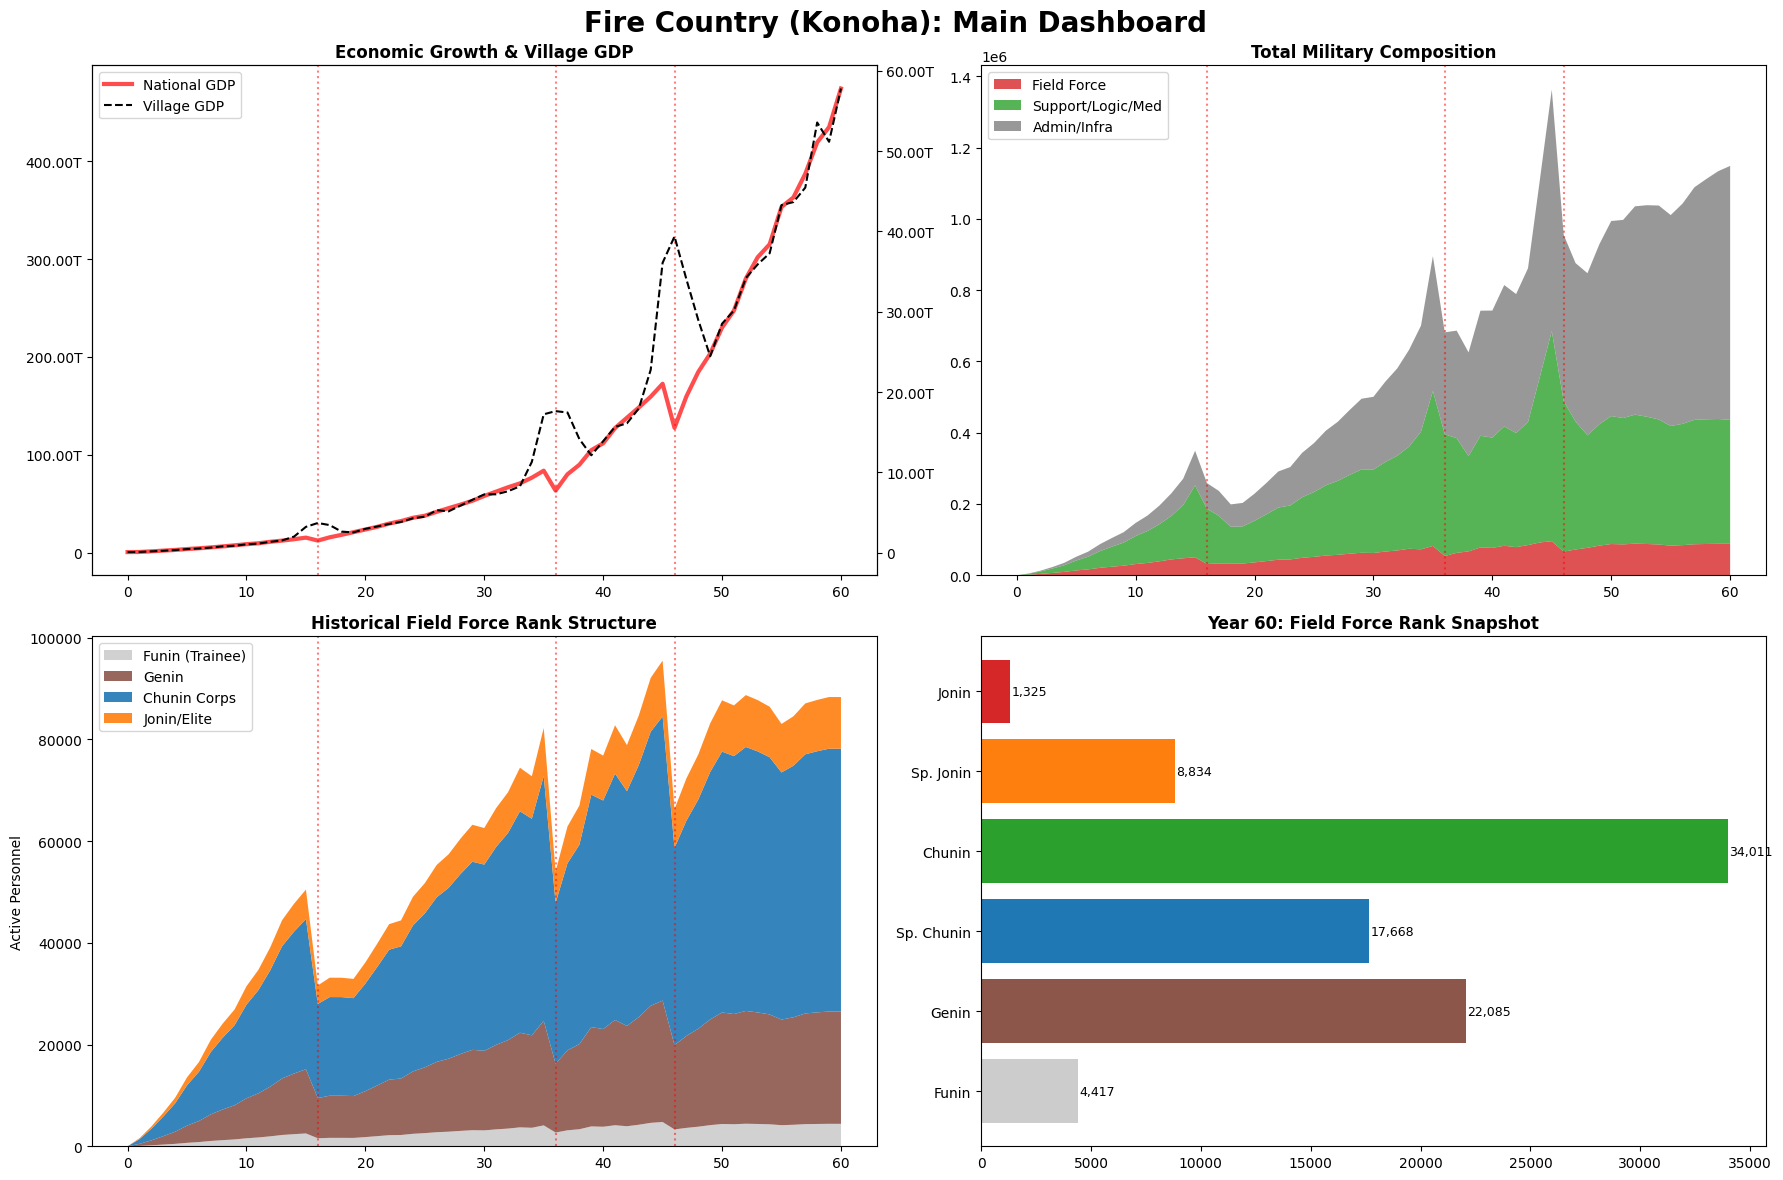

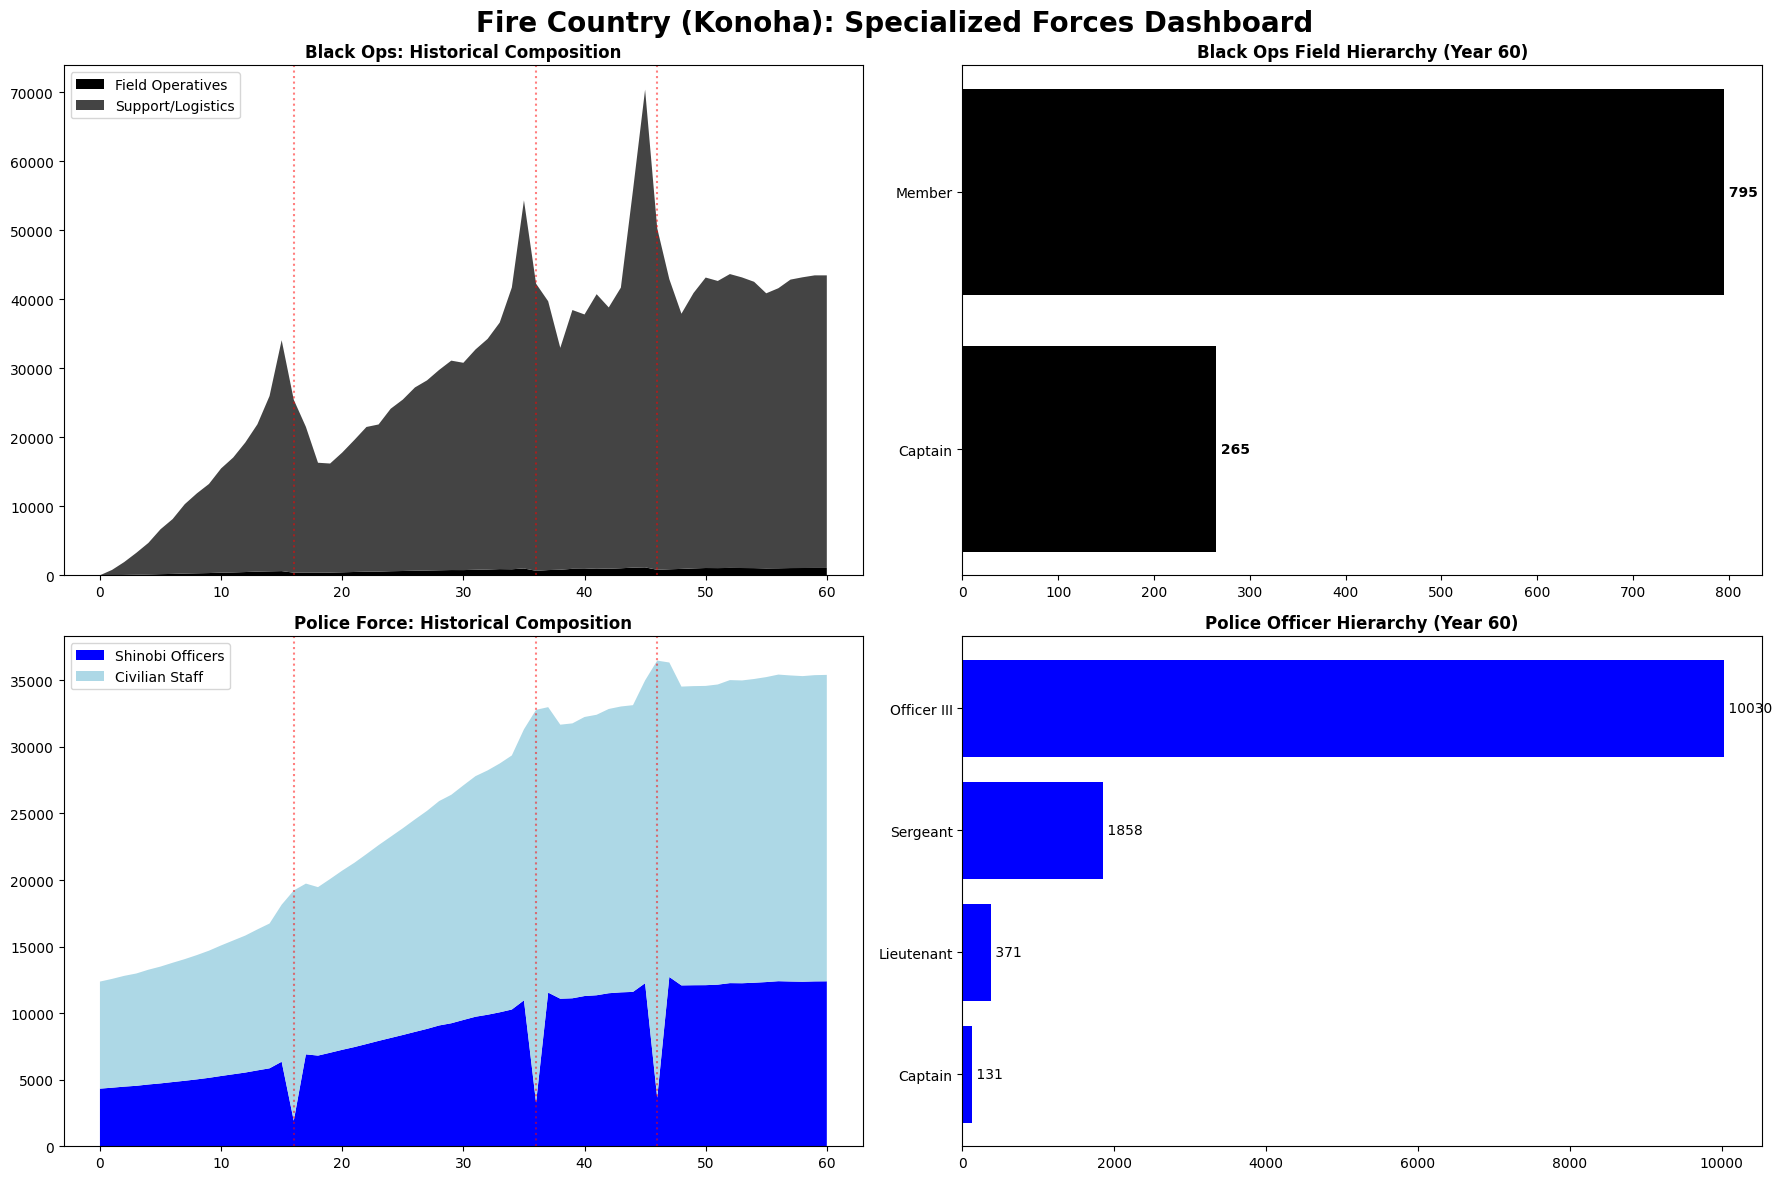

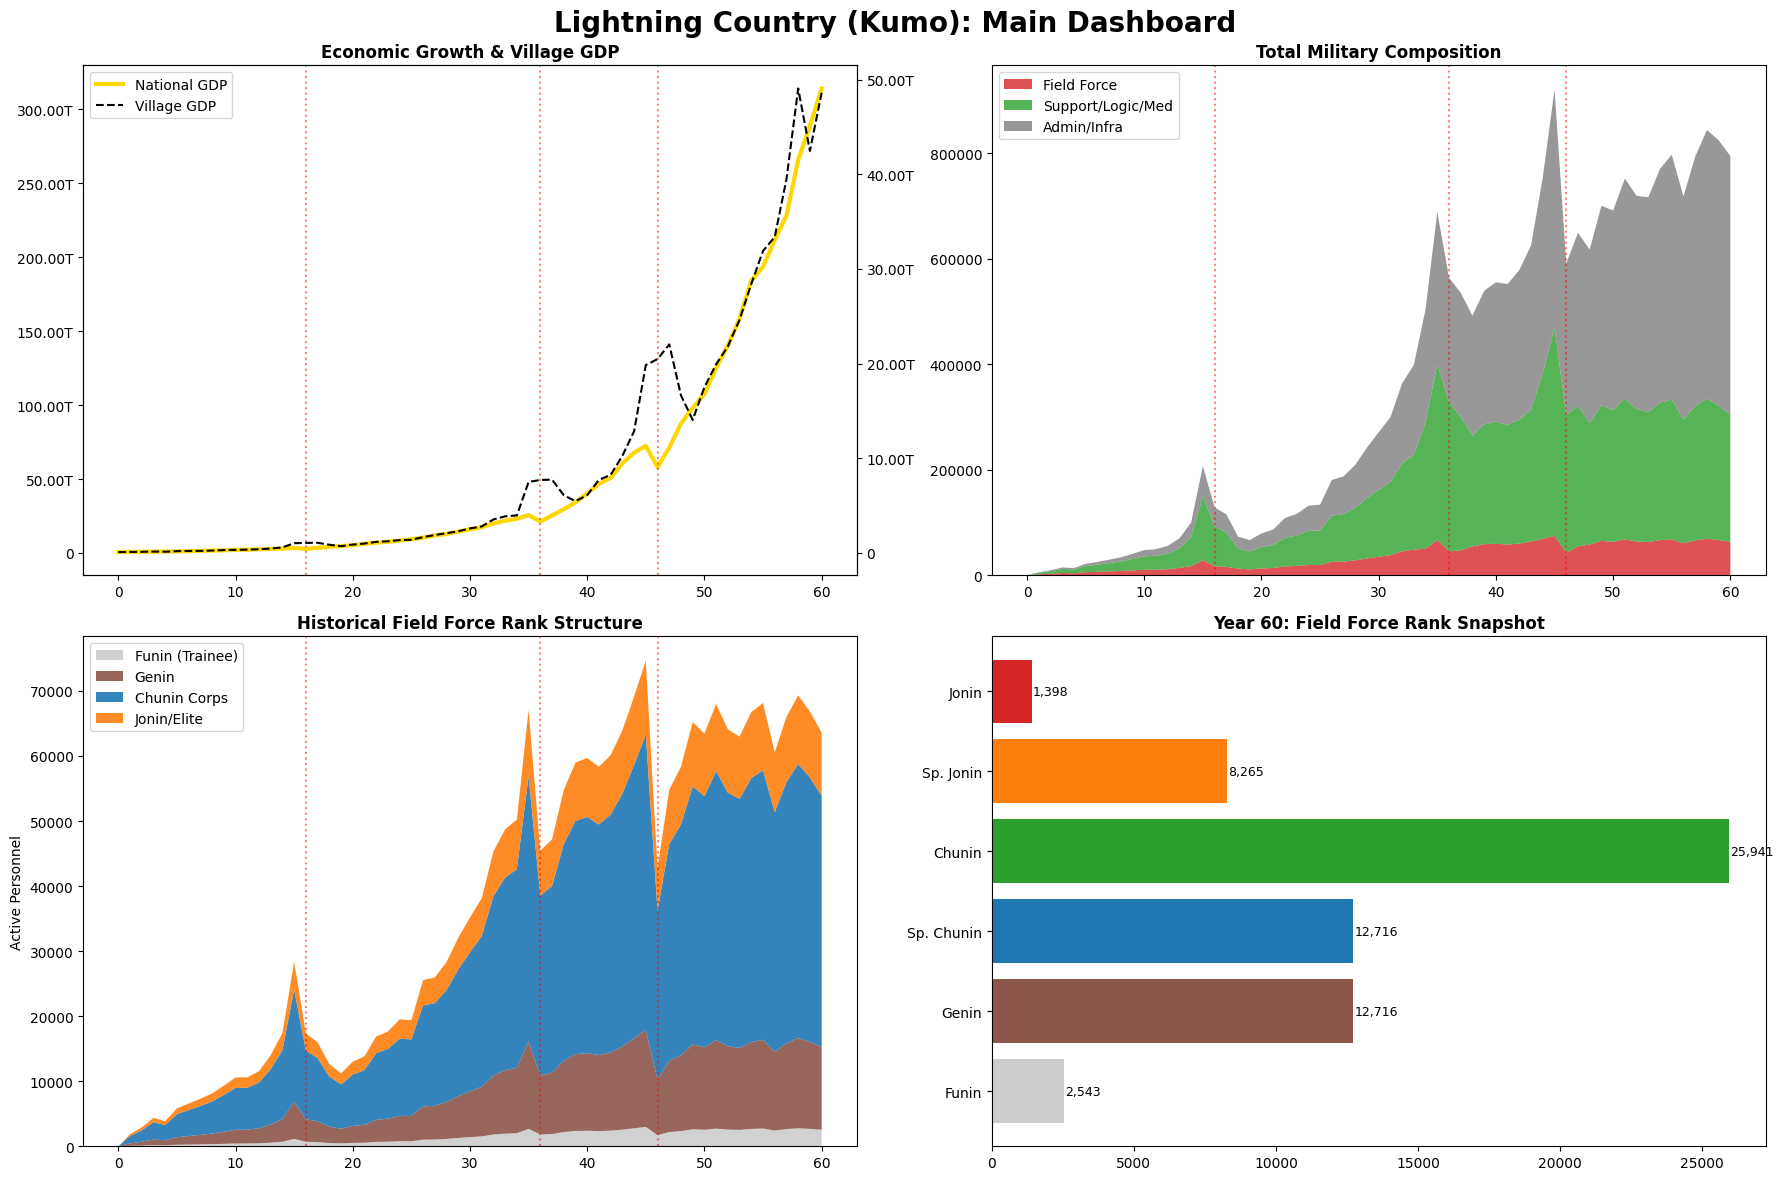

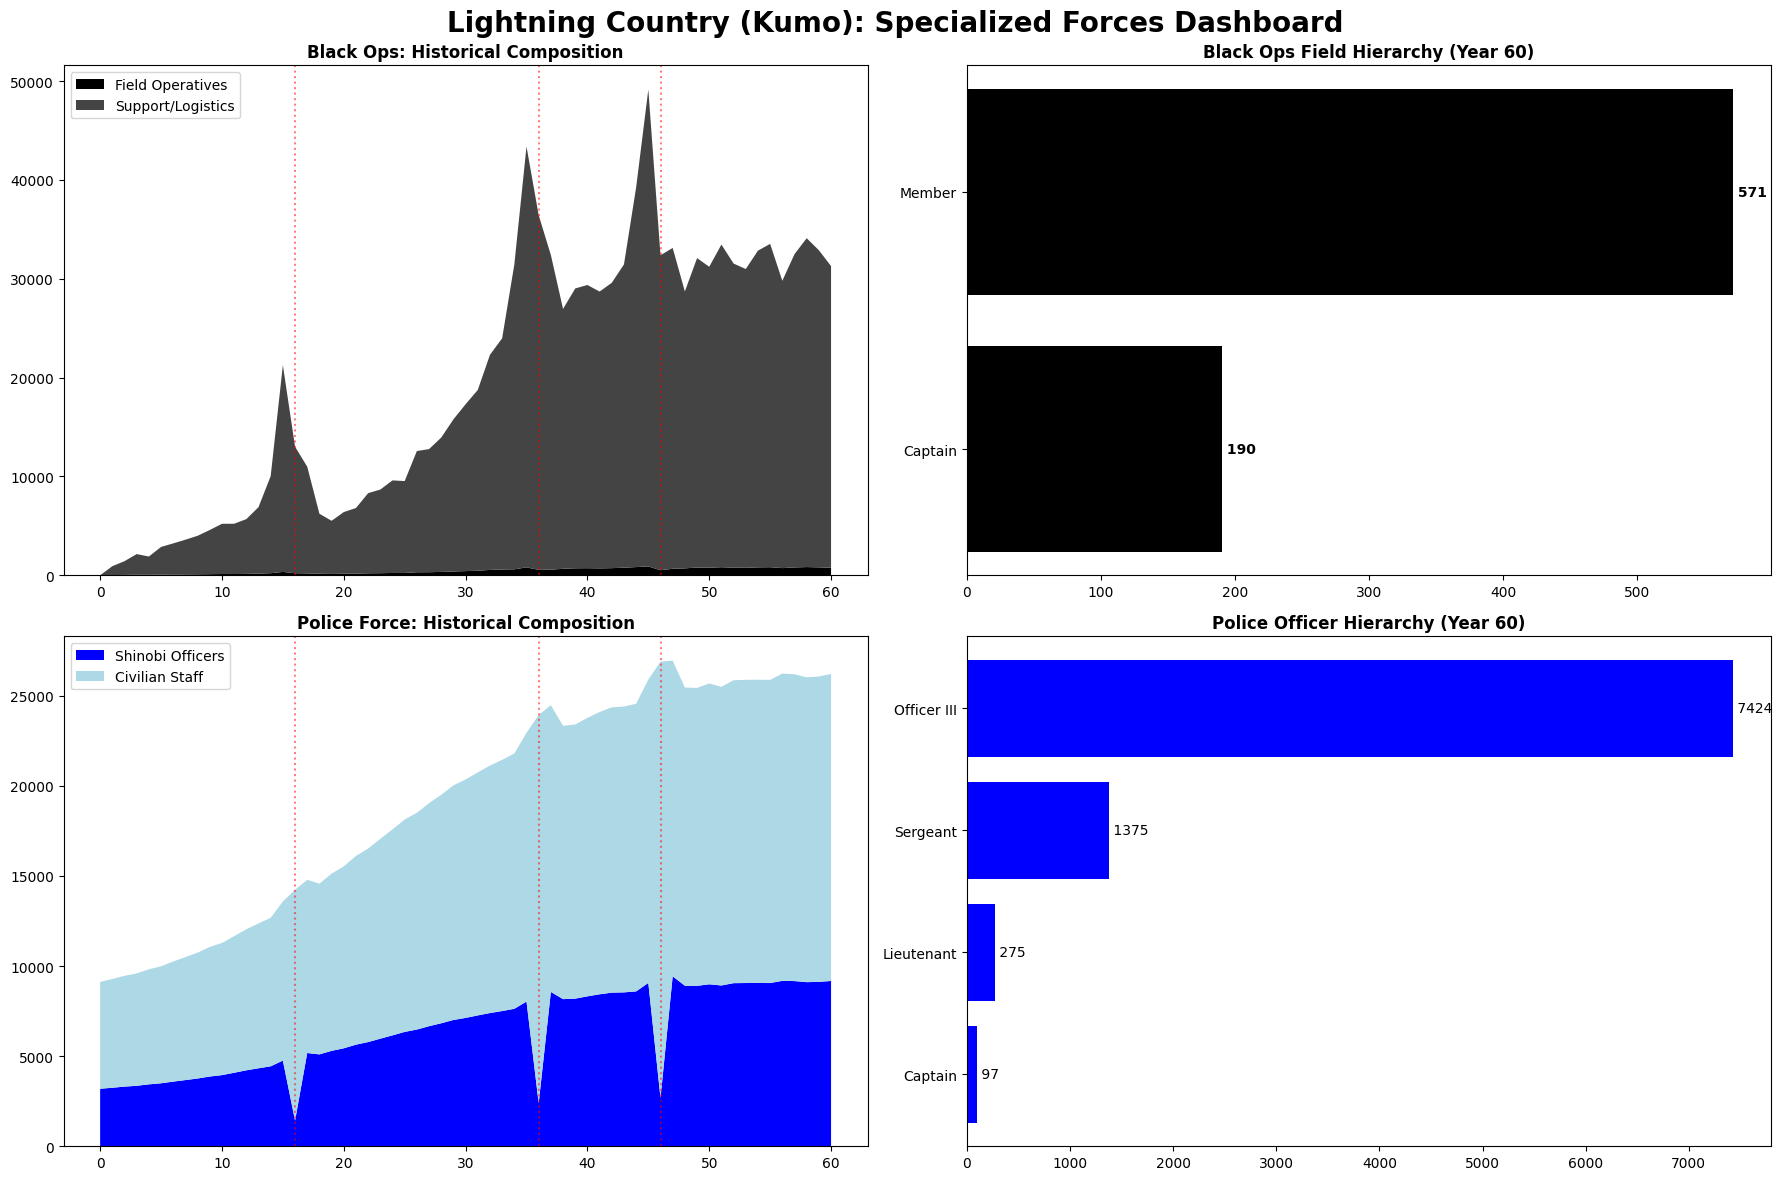

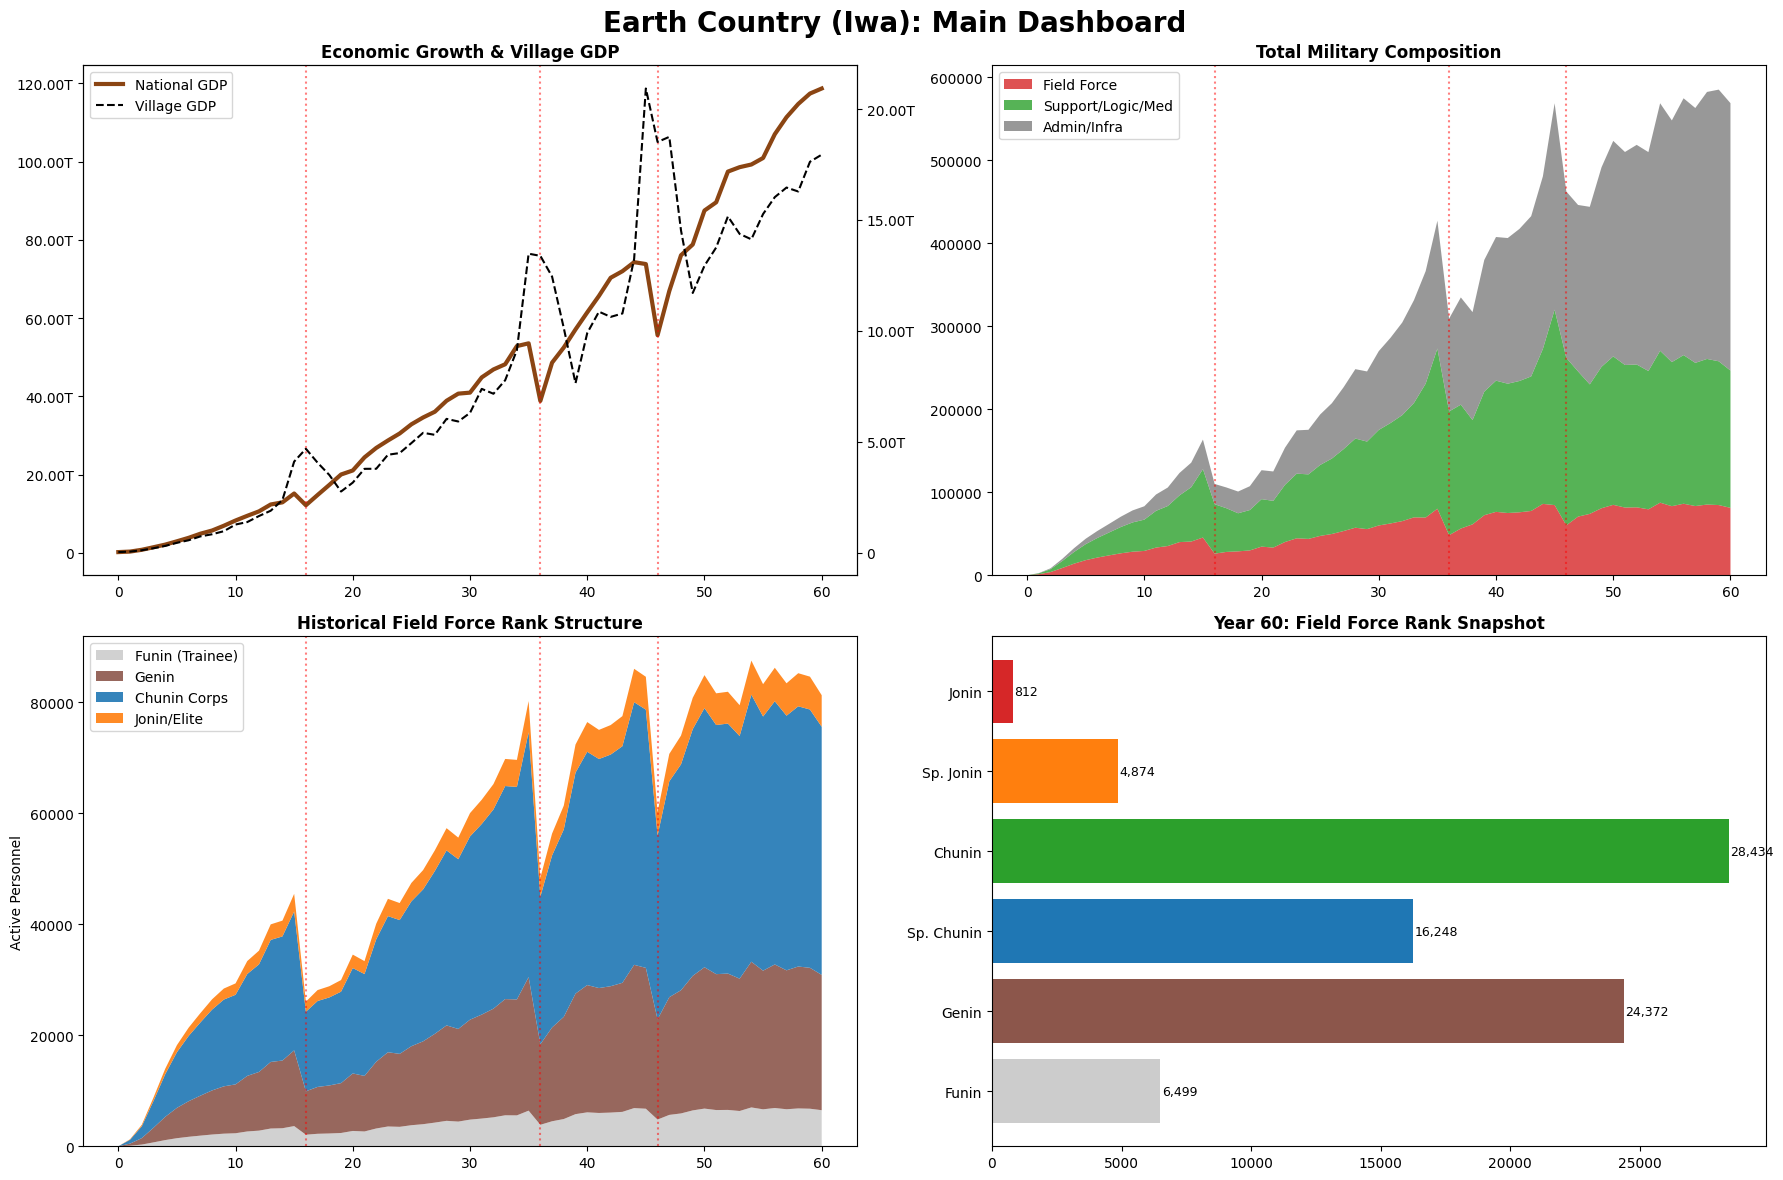

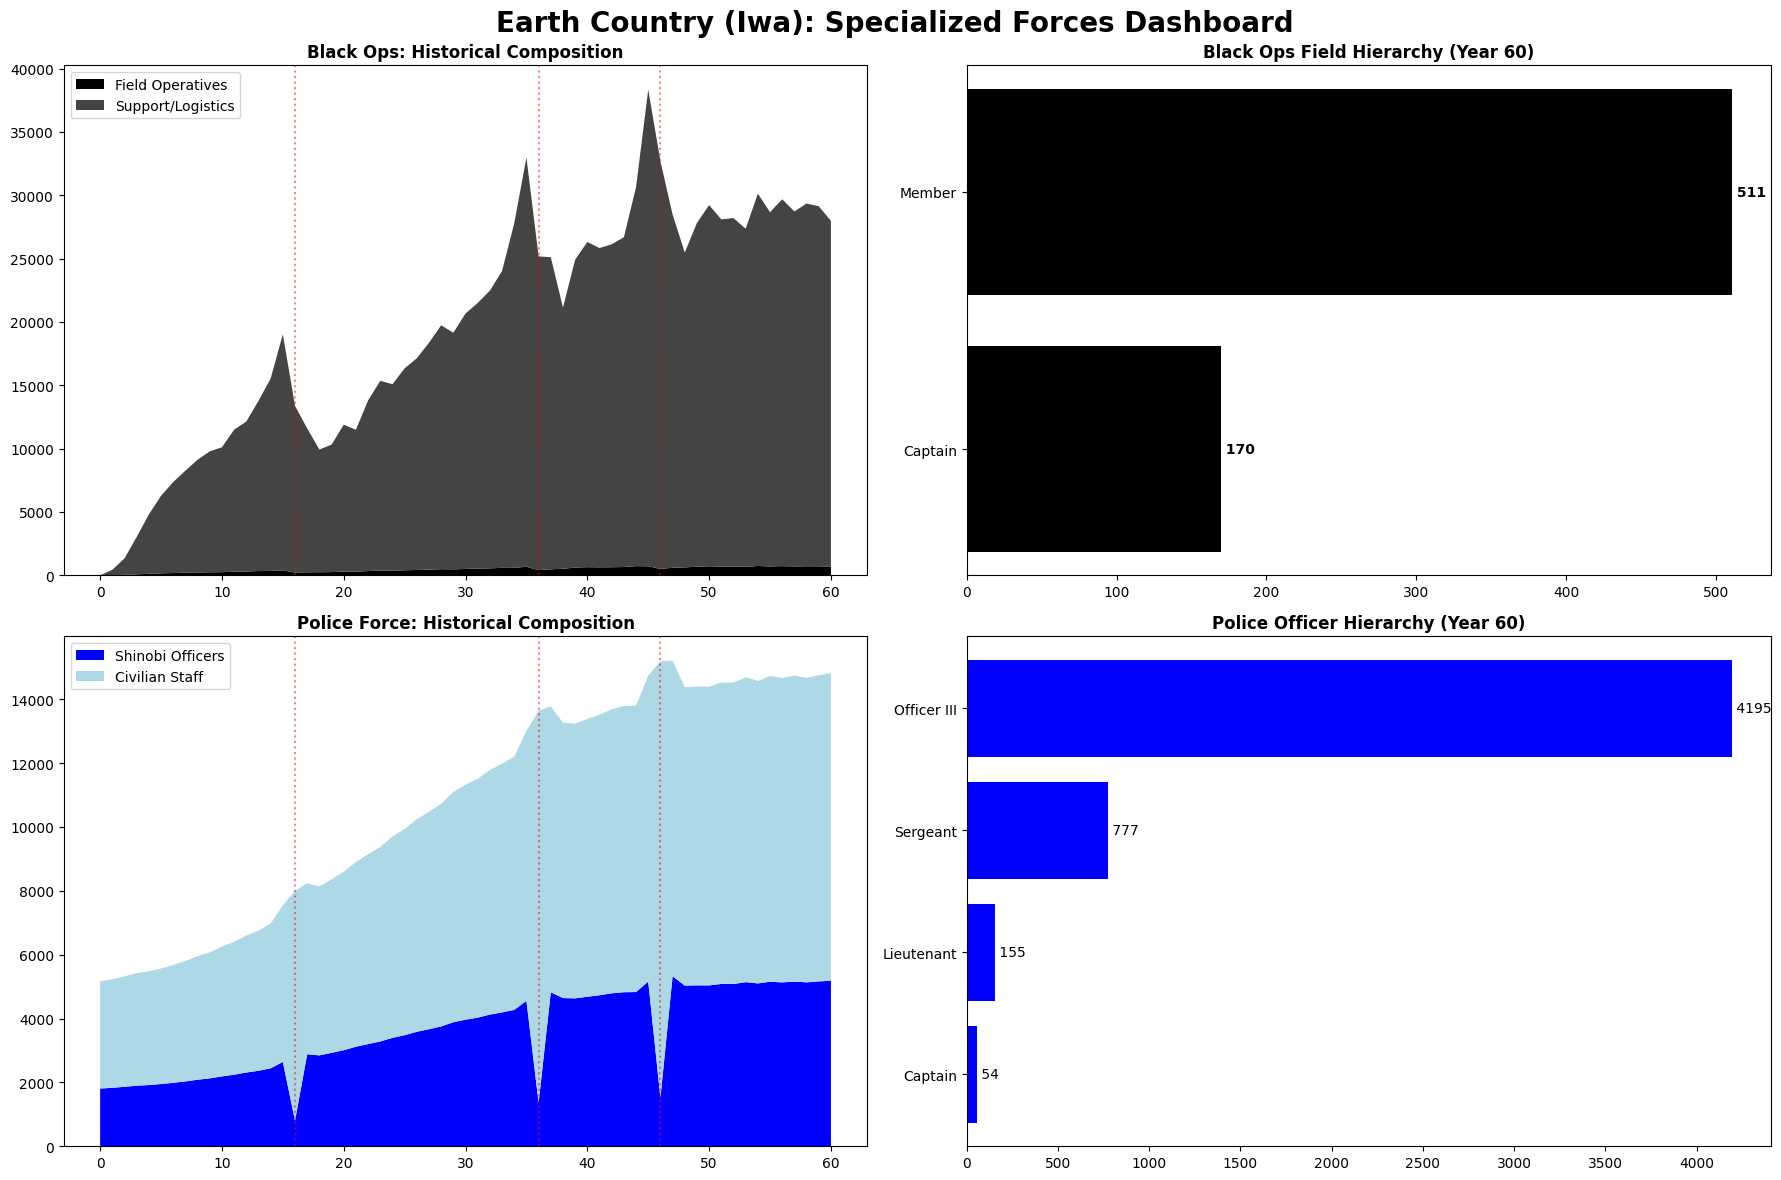

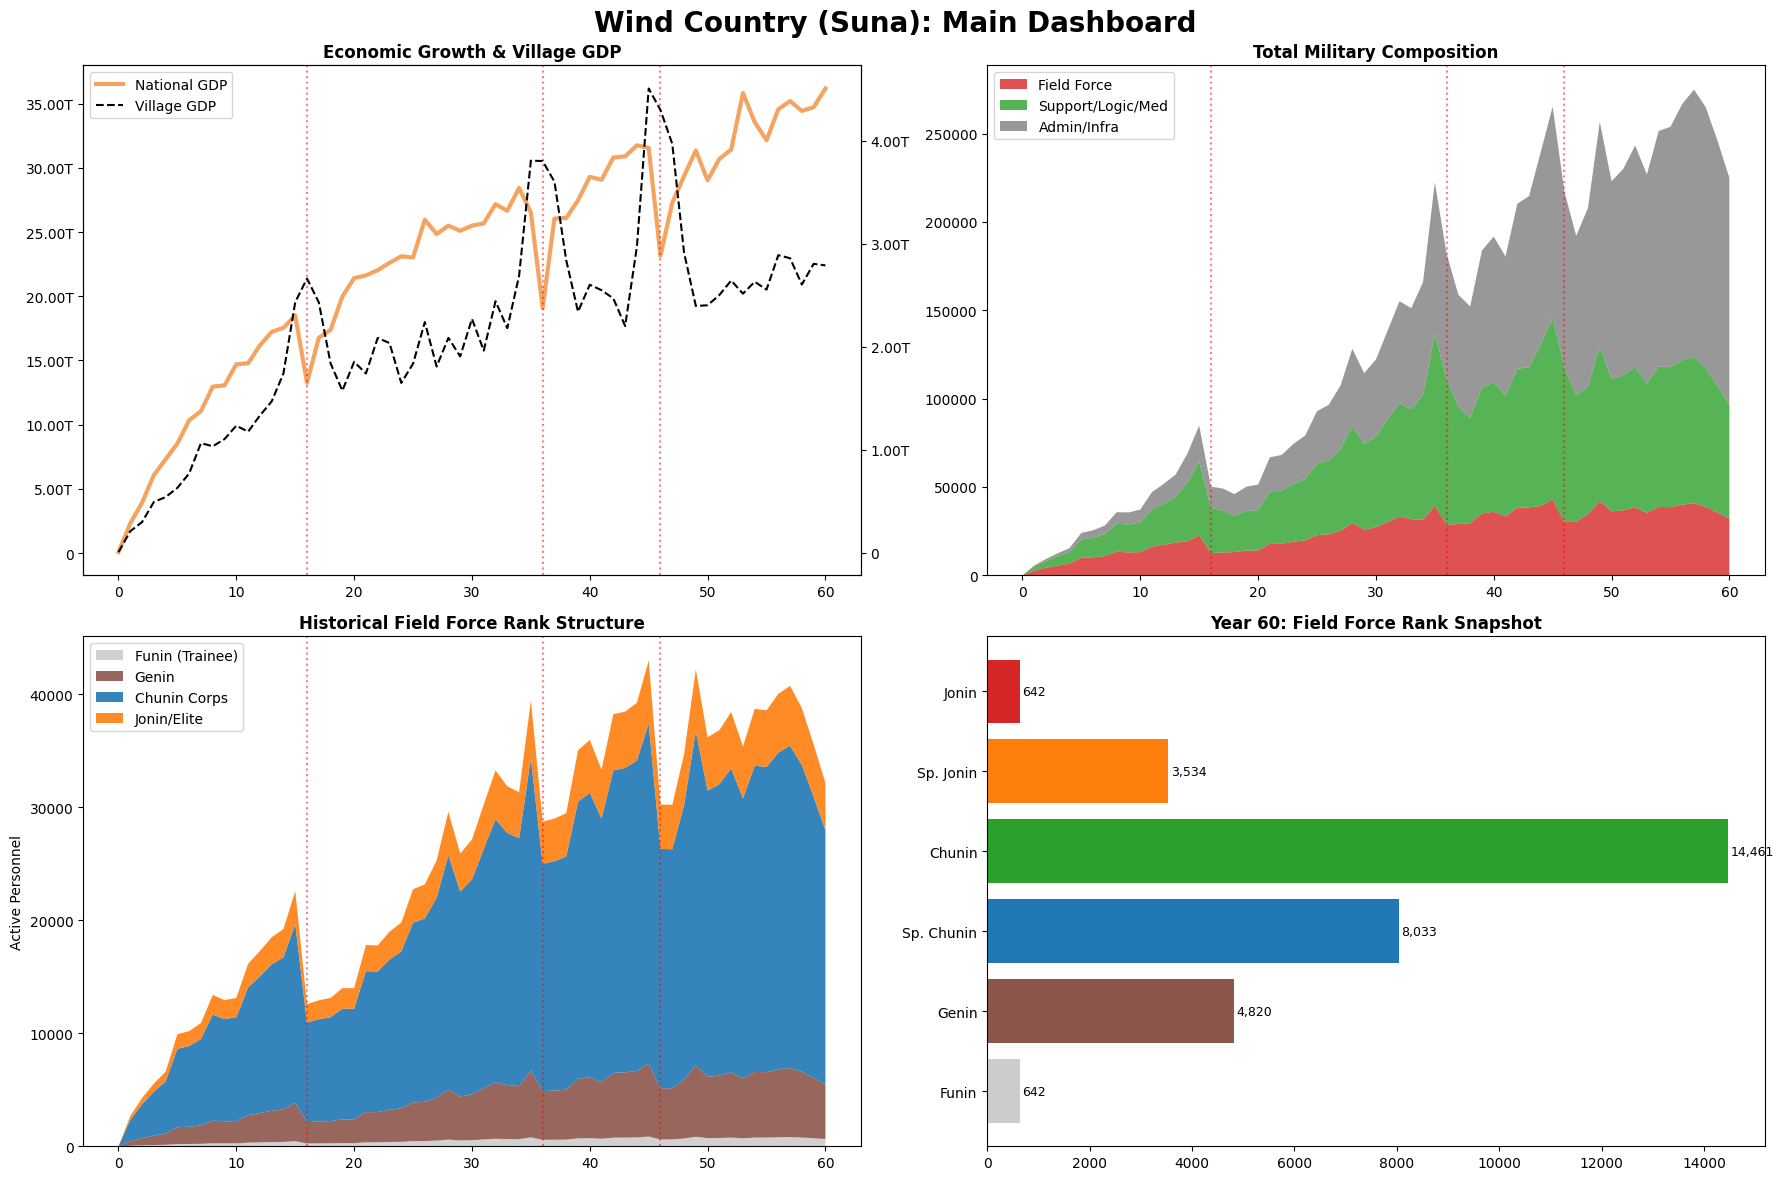

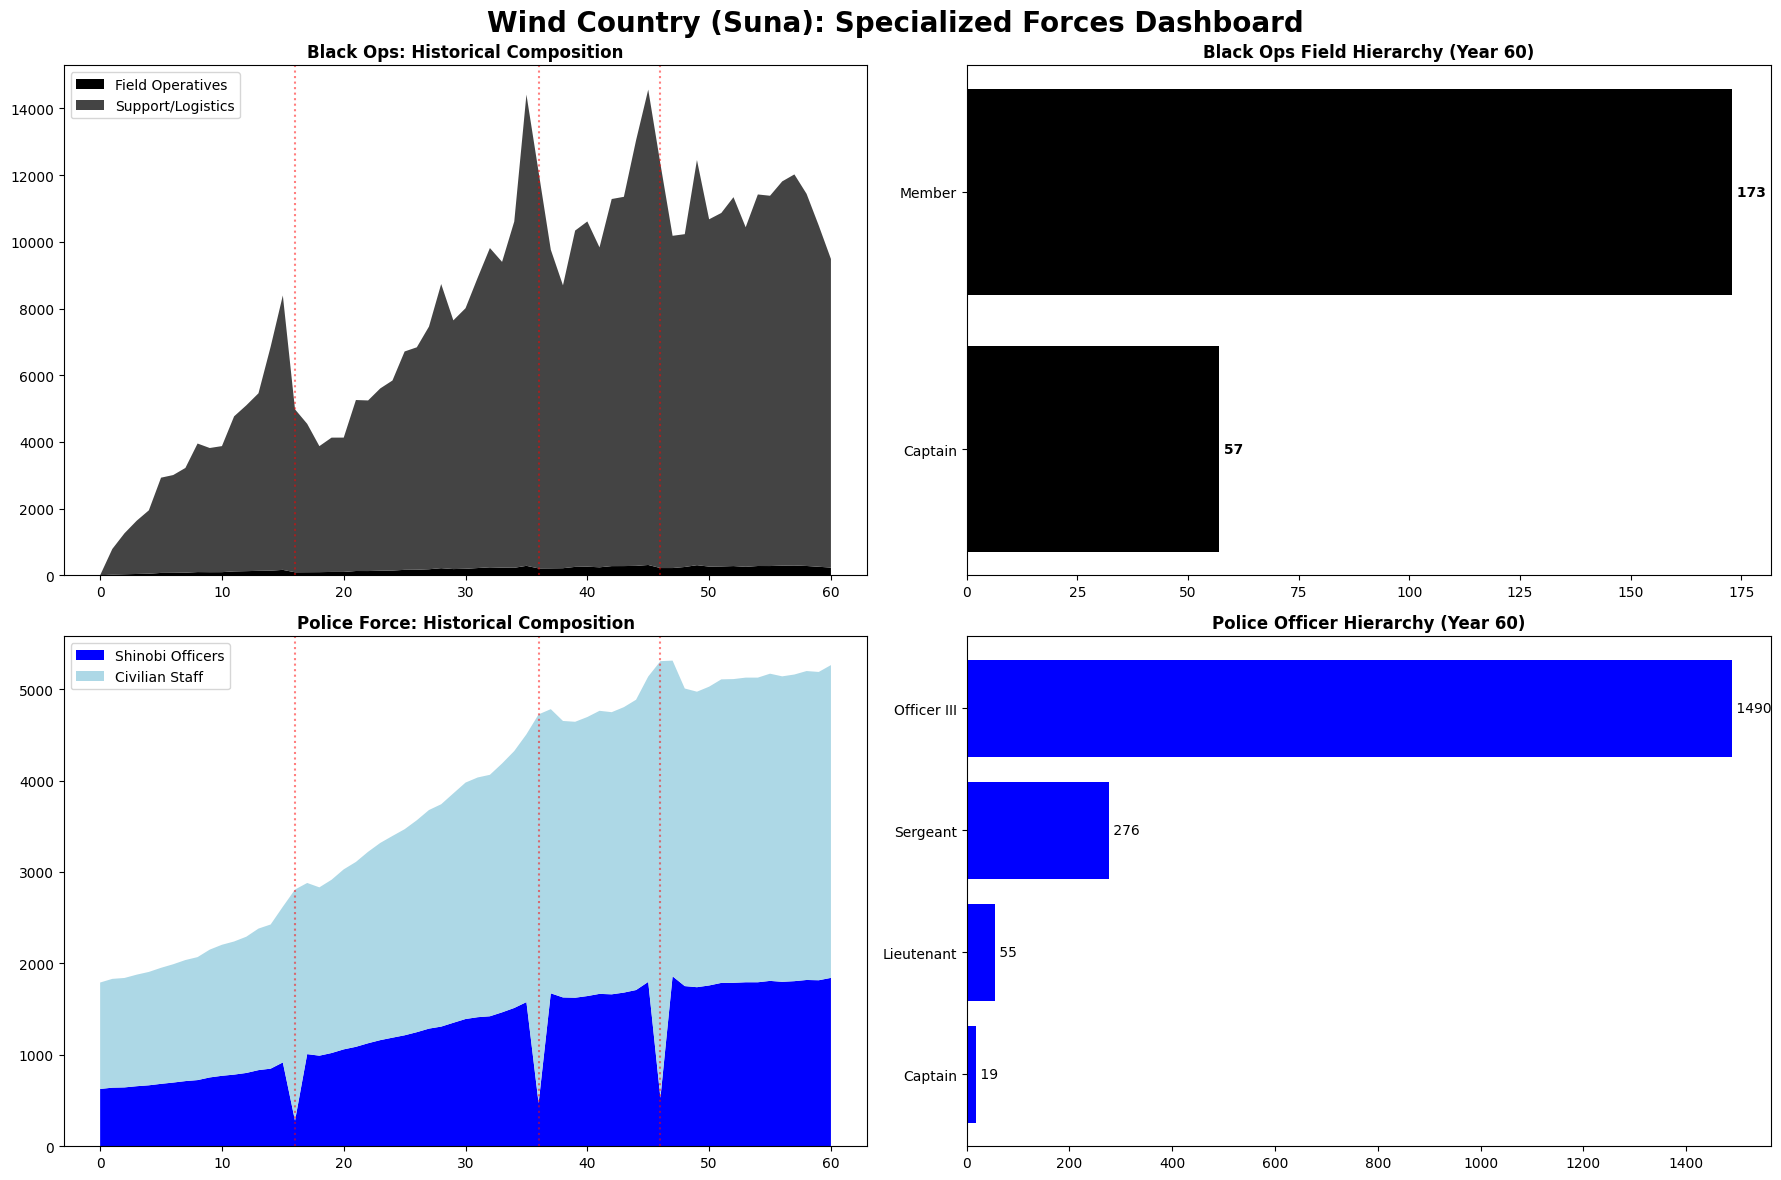

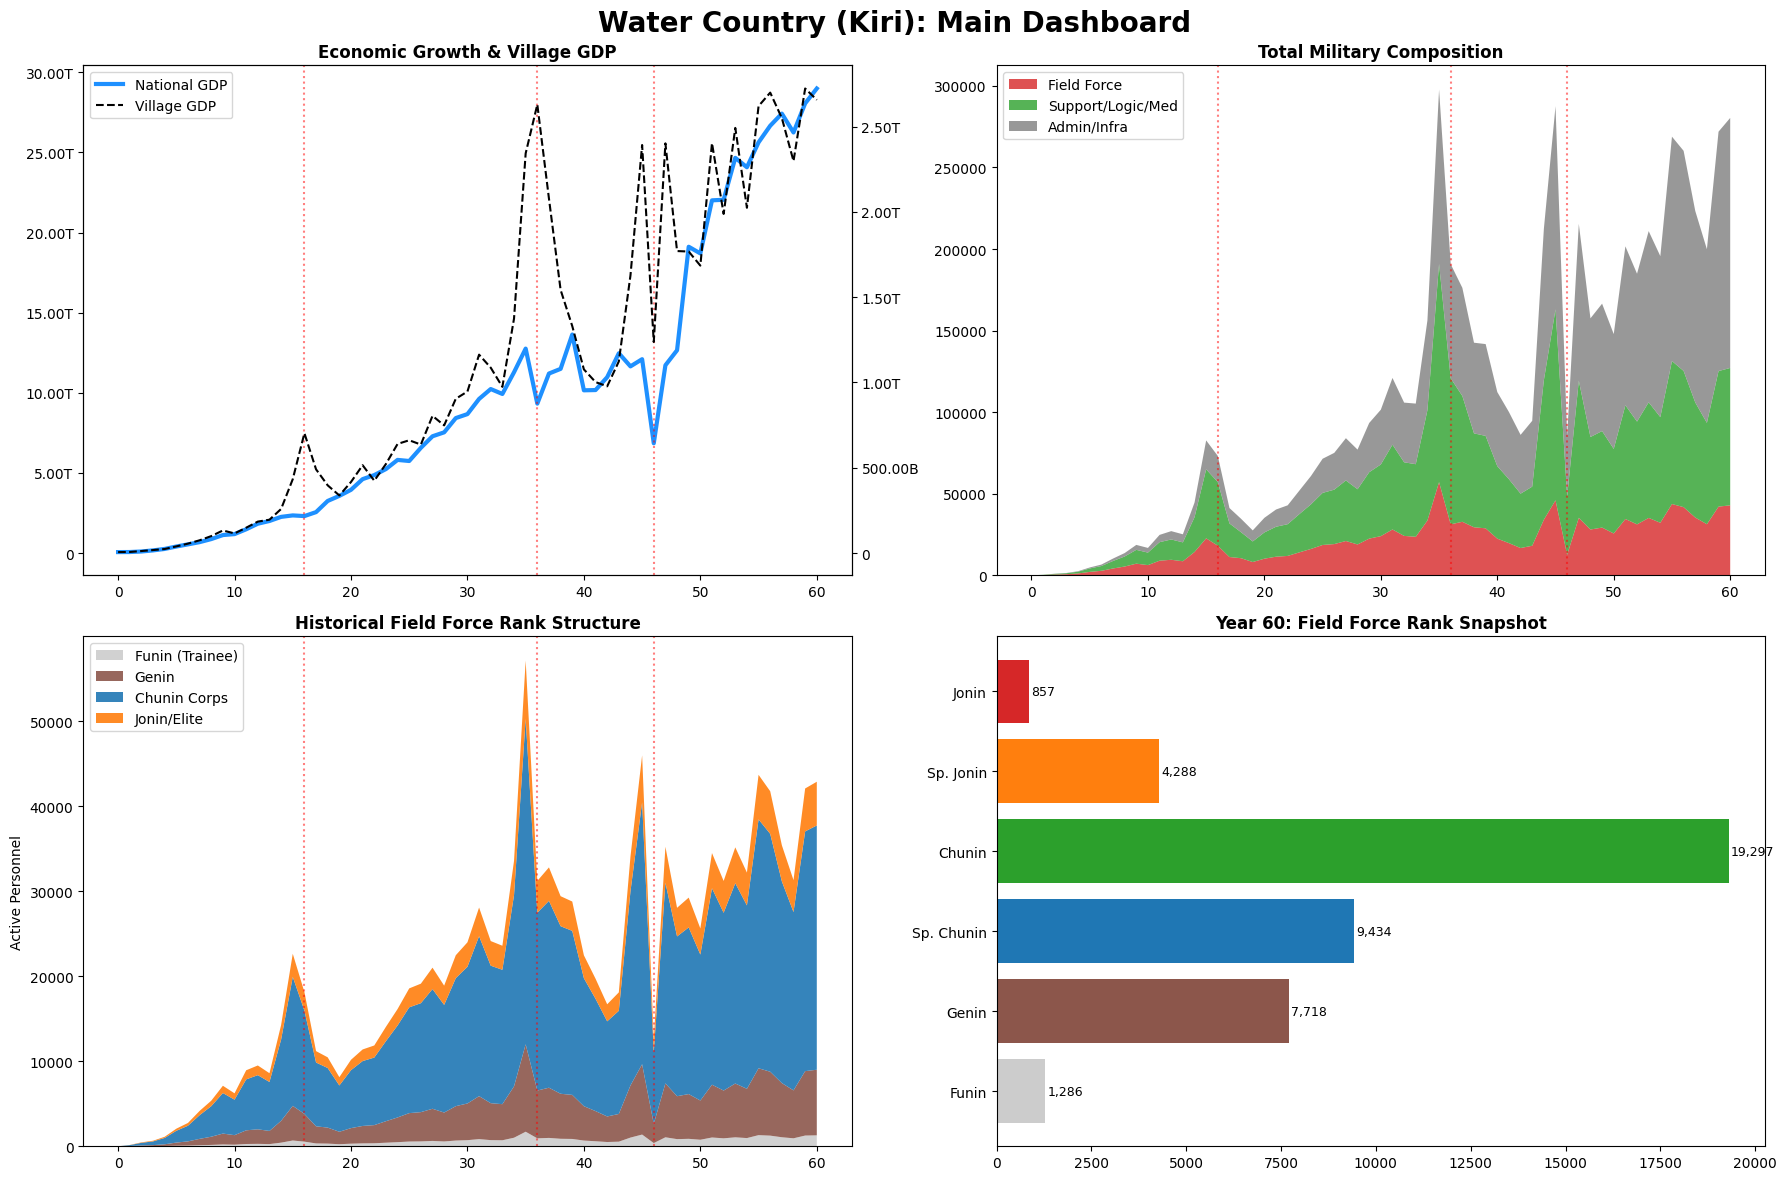

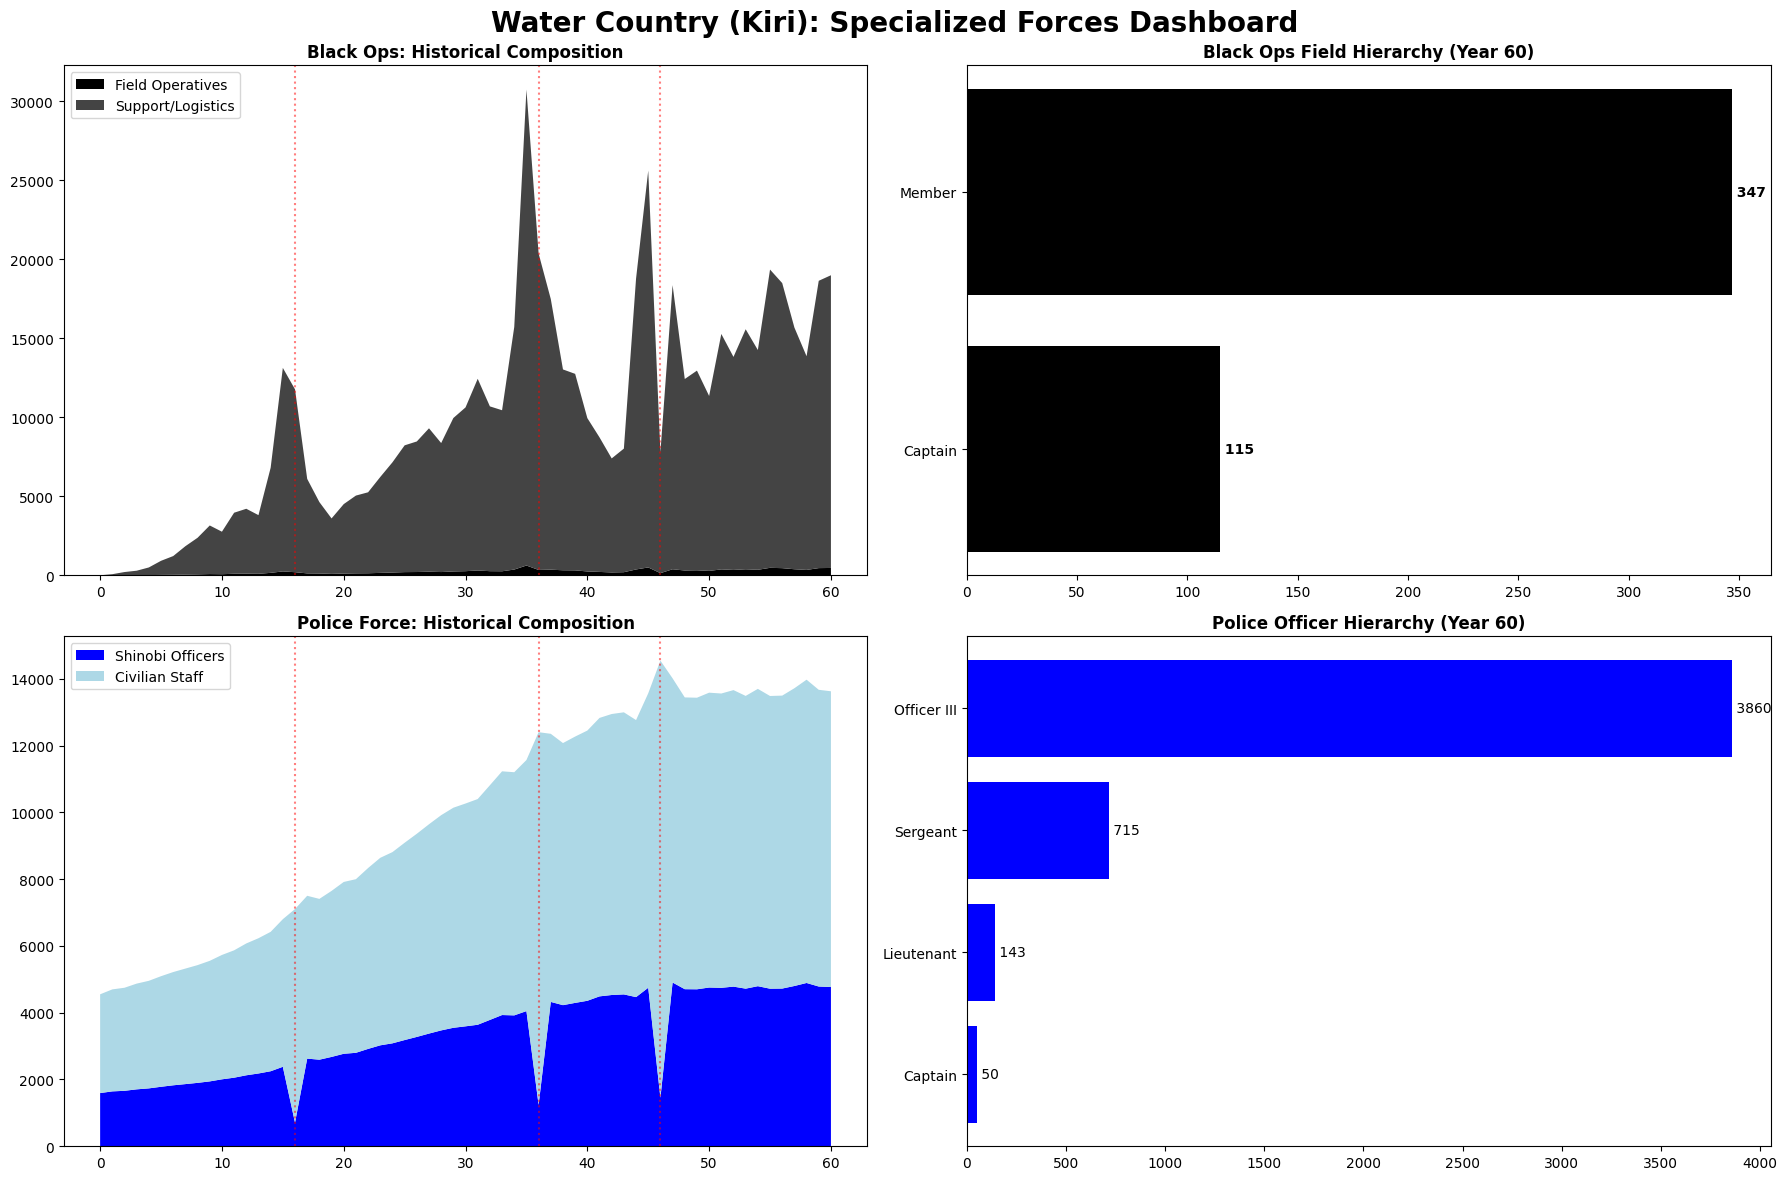

/tmp/ipython-input-1002965097.py:527: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row_data['Nation'] = pd.Categorical(row_data['Nation'], categories=nations, ordered=True)
/tmp/ipython-input-1002965097.py:527: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row_data['Nation'] = pd.Categorical(row_data['Nation'], categories=nations, ordered=True)
/tmp/ipython-input-1002965097.py:527: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

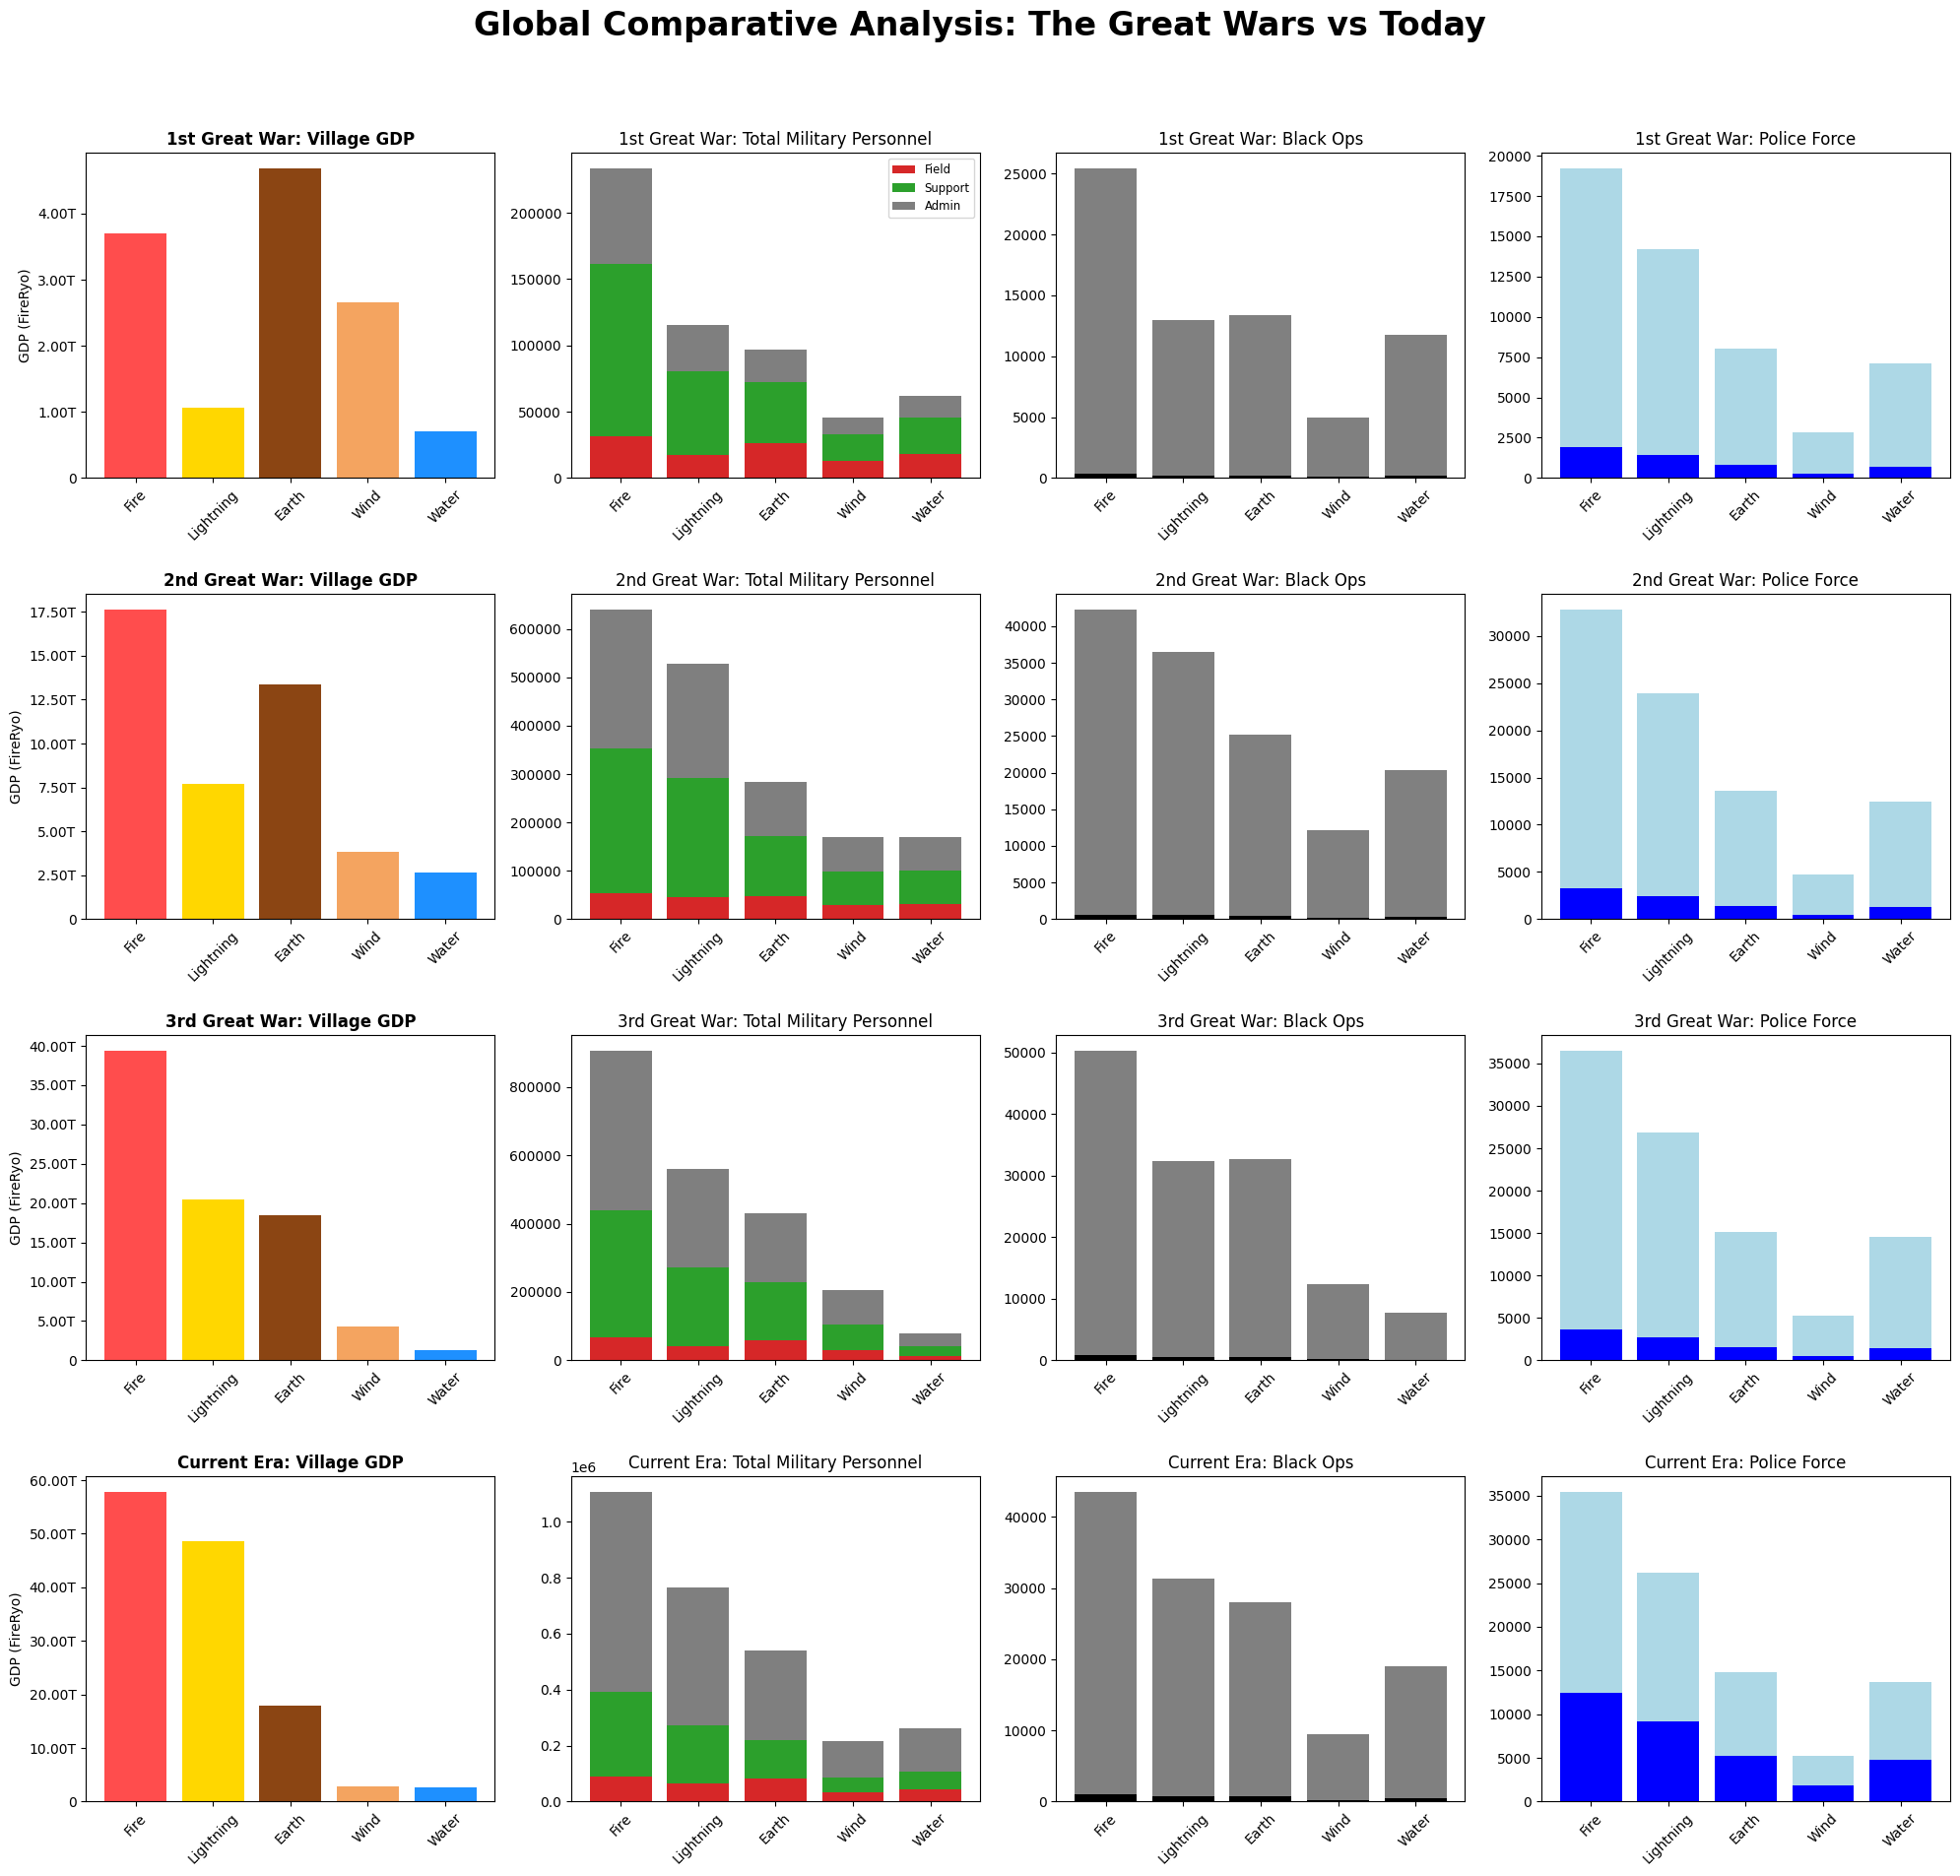

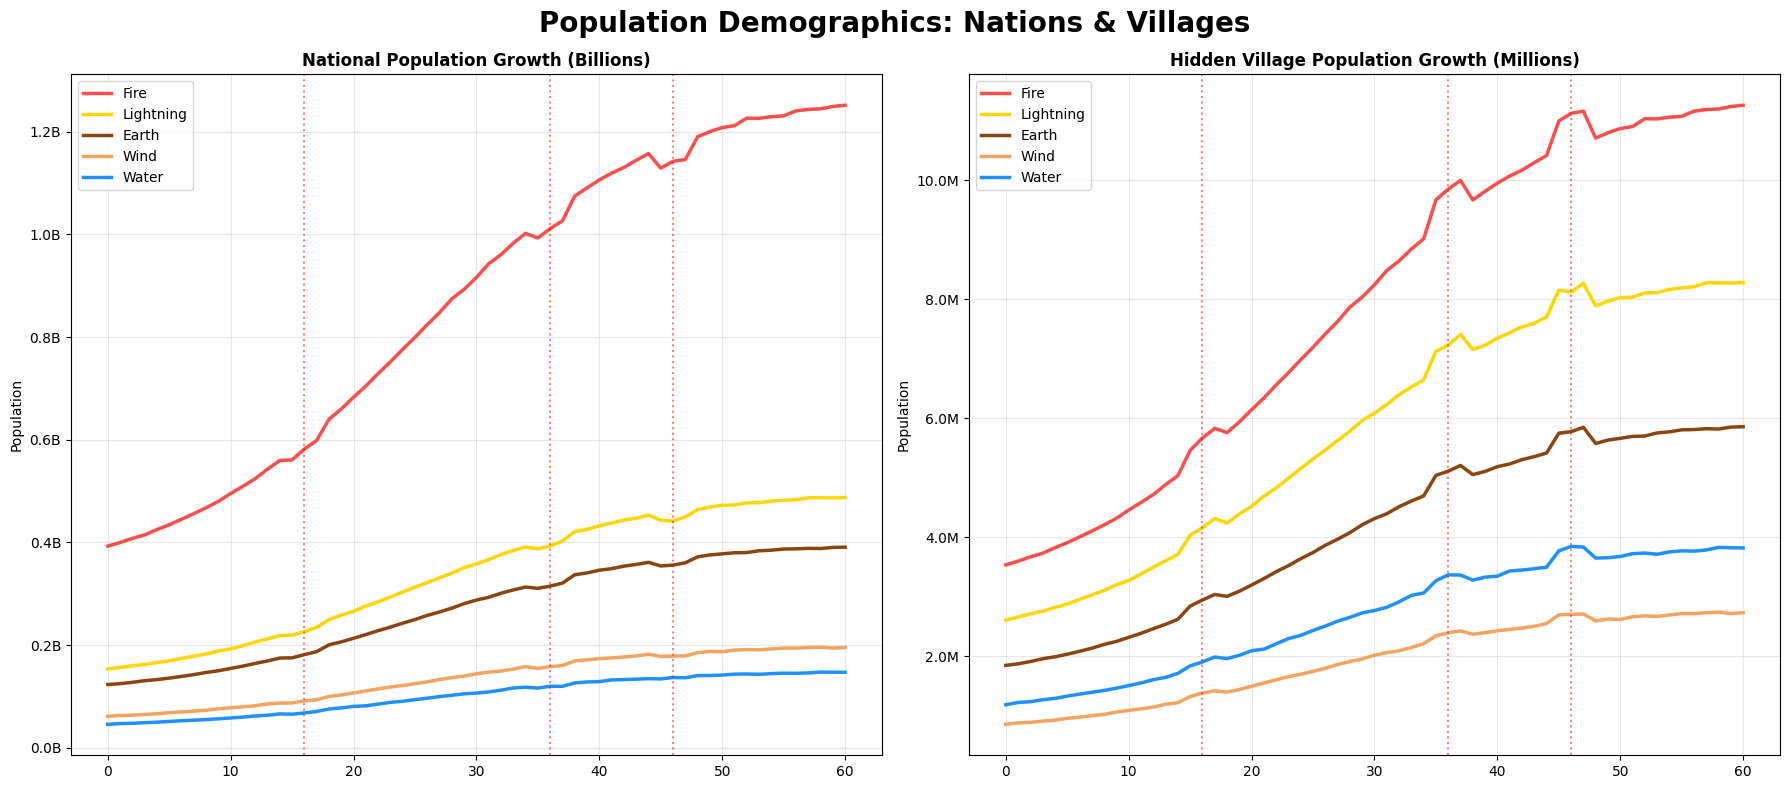

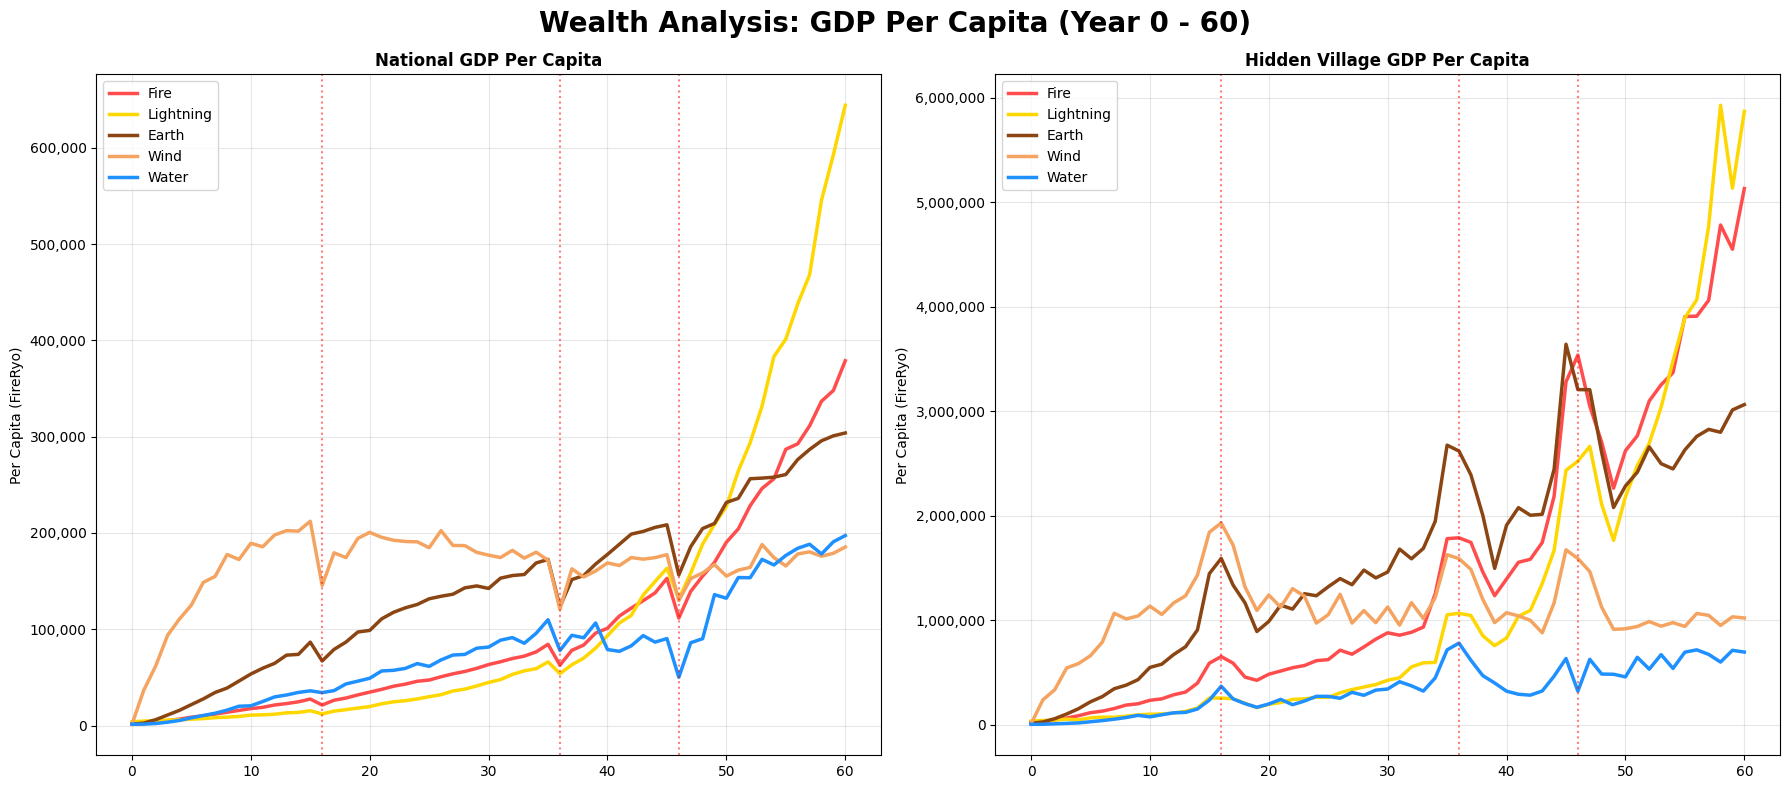

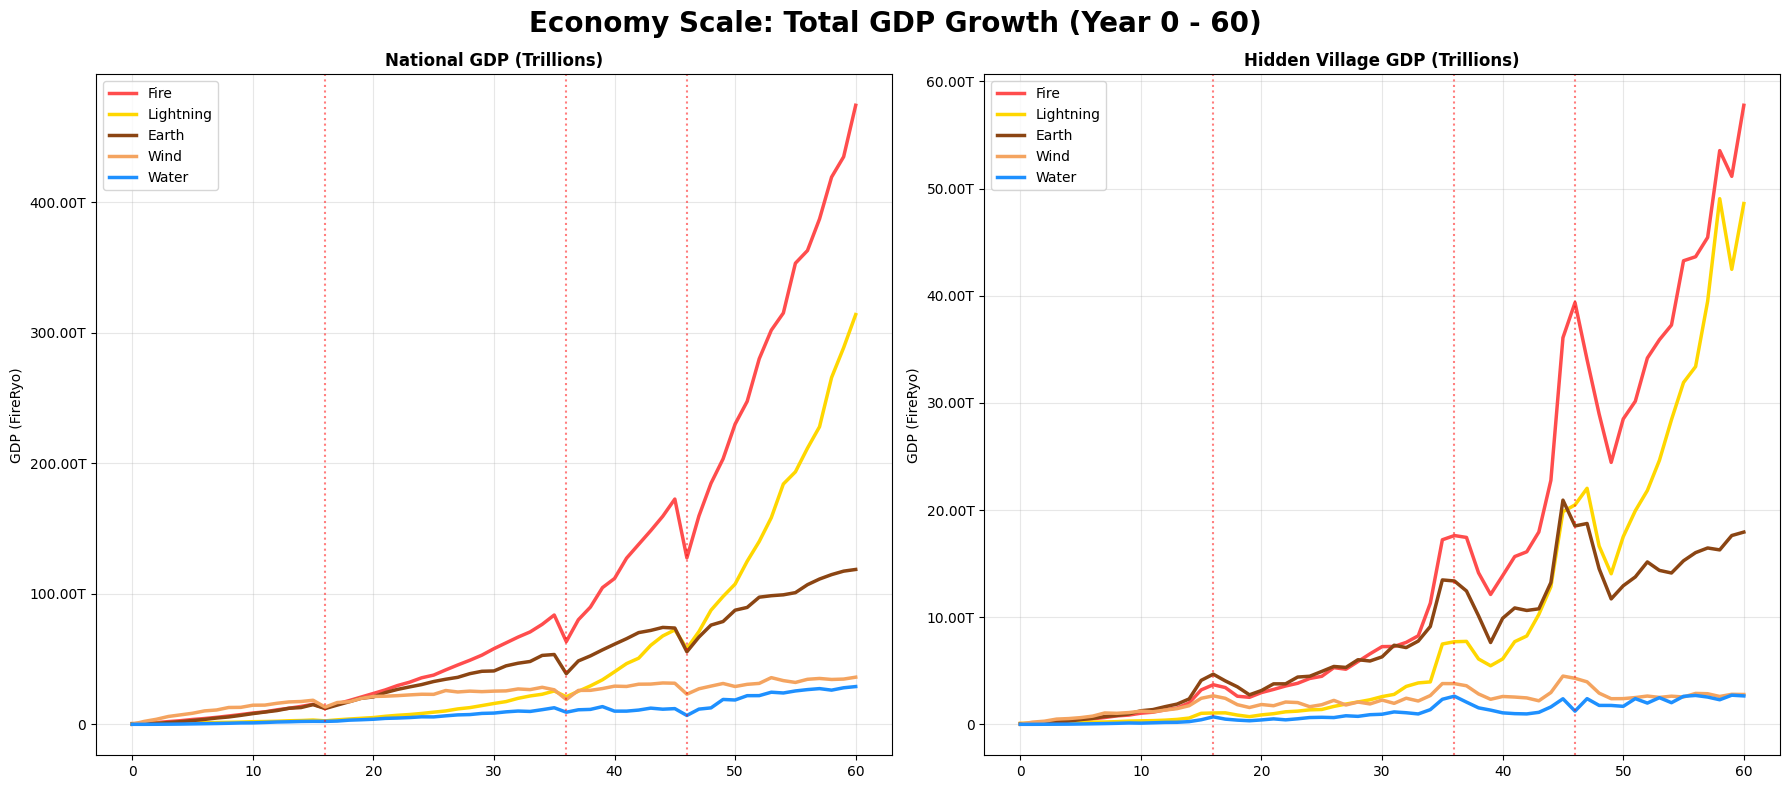

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import math

# Set Seed for Reproducible "Randomness"
np.random.seed(42)

# ==========================================
# PART 1: CONFIGURATION & DOCTRINES
# ==========================================

# 1 FireRyo = 0.1 USD.
WAR_YEARS = [16, 36, 46]

# --- 1.1 Village Specific Doctrines ---
RANK_DOCTRINES = {
    "Fire": {
        "Funin": 0.05, "Genin": 0.25, "Special Chunin": 0.20, "Chunin": 0.385, "Special Jonin": 0.10, "Jonin": 0.015,
        "Support_Ability": 1.0,
        "Black_Ops_Ratio_Mod": 1.0, "Police_Ratio_Mod": 1.0
    },
    "Lightning": {
        "Funin": 0.04, "Genin": 0.20, "Special Chunin": 0.20, "Chunin": 0.408, "Special Jonin": 0.13, "Jonin": 0.022,
        "Support_Ability": 1.15,
        "Black_Ops_Ratio_Mod": 1.0, "Police_Ratio_Mod": 1.0
    },
    "Earth": {
        "Funin": 0.08, "Genin": 0.30, "Special Chunin": 0.20, "Chunin": 0.35, "Special Jonin": 0.06, "Jonin": 0.01,
        "Support_Ability": 0.55,
        "Black_Ops_Ratio_Mod": 0.7,   "Police_Ratio_Mod": 0.8
    },
    "Wind": {
        "Funin": 0.02, "Genin": 0.15, "Special Chunin": 0.25, "Chunin": 0.45, "Special Jonin": 0.11, "Jonin": 0.02,
        "Support_Ability": 0.40,
        "Black_Ops_Ratio_Mod": 0.6, "Police_Ratio_Mod": 0.6
    },
    "Water": {
        "Funin": 0.03, "Genin": 0.18, "Special Chunin": 0.22, "Chunin": 0.45, "Special Jonin": 0.10, "Jonin": 0.02,
        "Support_Ability": 0.60,
        "Black_Ops_Ratio_Mod": 0.9, "Police_Ratio_Mod": 1.1
    }
}

RAW_NATIONS_DATA = {
    "Fire": {
        "full_name": "Fire Country (Konoha)",
        "pop_target": 1_280_000_000,
        "gdp_target": 480_000_000_000_000,
        "village_gdp_share": 0.12,
        "gdp_start_b": 150,
        "village_pop_ratio": 0.009,
        "militarity_index": 1.0,
        "growth_style": "stable_exp",
        "volatility": 0.015,
        "color": "#ff4d4d"
    },
    "Lightning": {
        "full_name": "Lightning Country (Kumo)",
        "pop_target": 500_000_000,
        "gdp_target": 320_000_000_000_000,
        "village_gdp_share": 0.16,
        "gdp_start_b": 80,
        "village_pop_ratio": 0.017,
        "militarity_index": 1.2,
        "growth_style": "tech_boom",
        "volatility": 0.025,
        "color": "#ffd700"
    },
    "Earth": {
        "full_name": "Earth Country (Iwa)",
        "pop_target": 400_000_000,
        "gdp_target": 120_000_000_000_000,
        "village_gdp_share": 0.15,
        "gdp_start_b": 60,
        "village_pop_ratio": 0.015,
        "militarity_index": 1.1,
        "growth_style": "linear_industrial",
        "volatility": 0.02,
        "color": "#8b4513"
    },
    "Wind": {
        "full_name": "Wind Country (Suna)",
        "pop_target": 200_000_000,
        "gdp_target": 35_000_000_000_000,
        "village_gdp_share": 0.08,
        "gdp_start_b": 40,
        "village_pop_ratio": 0.014,
        "militarity_index": 0.8,
        "growth_style": "resource_curse",
        "volatility": 0.04,
        "color": "#f4a460"
    },
    "Water": {
        "full_name": "Water Country (Kiri)",
        "pop_target": 150_000_000,
        "gdp_target": 30_000_000_000_000,
        "village_gdp_share": 0.10,
        "gdp_start_b": 35,
        "village_pop_ratio": 0.026,
        "militarity_index": 1.3,
        "growth_style": "crisis_crash",
        "volatility": 0.05,
        "color": "#1e90ff"
    }
}

# --- Specialized Unit Doctrines ---
BLACK_OPS_FIELD_RANKS = {"Captain": 0.25, "Member": 0.75}
BLACK_OPS_FIELD_PERCENT = 0.012
BLACK_OPS_SUPPORT_RATIO = 40

POLICE_SOURCE = {"Genin": 0.10, "Chunin": 0.20, "Special Chunin": 0.60, "Special Jonin": 0.08, "Jonin": 0.02}
OFFICERS_PER_1000_CIV = 3.5
POLICE_SHINOBI_RATIO = 0.35
POLICE_PYRAMID = {
    "Captain": 0.0106,
    "Lieutenant": 0.03,
    "Sergeant": 0.15,
    "Officer III": 0.8094
}

# ==========================================
# PART 2: SIMULATION LOGIC
# ==========================================

def format_currency(value):
    if value >= 1_000_000_000_000: return f"{value/1_000_000_000_000:.2f}T"
    elif value >= 1_000_000_000: return f"{value/1_000_000_000:.2f}B"
    elif value >= 1_000_000: return f"{value/1_000_000:.2f}M"
    return f"{value:.0f}"

def get_realism_noise(volatility, is_war_period=False):
    sigma = volatility
    if is_war_period:
        sigma *= 2.0
    return np.random.normal(1.0, sigma)

def get_learning_curve_modifier(year):
    if year <= 16:
        return 0.55 * (year / 16) ** 0.8
    elif year <= 36:
        progress = (year - 16) / 20
        return 0.55 + (0.15 * progress)
    elif year <= 46:
        progress = (year - 36) / 10
        return 0.70 + (0.15 * progress)
    else:
        progress = (year - 46) / 14
        return 0.85 + (0.15 * progress)

def get_personnel_war_modifier(year):
    mult = 1.0
    if year == 16: return 0.55
    if 17 <= year <= 20:
        recovery_progress = (year - 16) / 4
        return 0.55 + (0.10 * recovery_progress)
    elif 21 <= year <= 25:
        recovery_progress = (year - 20) / 5
        return 0.65 + (0.20 * recovery_progress)
    elif 26 <= year <= 32:
        recovery_progress = (year - 25) / 7
        return 0.85 + (0.15 * recovery_progress)

    for war_year in [36, 46]:
        diff = year - war_year
        if diff == -3: mult = 1.02
        elif diff == -2: mult = 1.05
        elif diff == -1: mult = 1.08
        elif diff == 0: mult = 0.75
        elif diff == 1: mult = 0.80
        elif diff == 2: mult = 0.90
    return mult

def get_war_budget_modifier(year):
    multiplier = 1.0
    for war_year in WAR_YEARS:
        diff = year - war_year
        if diff == 0: multiplier = 2.5
        elif diff == -1: multiplier = 1.8
        elif diff == -2: multiplier = 1.2
        elif diff == 1: multiplier = 1.8
        elif diff == 2: multiplier = 1.3
    return multiplier

def get_gdp_modifier(year, style):
    t = year / 60.0
    shock = 1.0
    base_shock = 0.70
    recovery_period = 6

    last_war_year = -999
    for wy in WAR_YEARS:
        if wy <= year: last_war_year = wy

    diff = year - last_war_year
    if diff == 0: shock = base_shock
    elif 0 < diff < recovery_period:
        progress = diff / recovery_period
        recovery_curve = math.sqrt(progress)
        shock = base_shock + ((1.0 - base_shock) * recovery_curve)

    val = t
    if style == "stable_exp": val = (math.exp(4 * t) - 1) / (math.exp(4) - 1)
    elif style == "tech_boom":
        val = (math.exp(6 * (t - 0.2)) - 0.1) / (math.exp(6 * 0.8) - 0.1)
        if val < 0: val = 0.01 * t
    elif style == "linear_industrial": val = t ** 1.5
    elif style == "resource_curse": val = (math.log(10 * t + 1)) / (math.log(11))
    elif style == "crisis_crash":
        base = t ** 1.8
        if 40 <= year <= 48: base *= 0.7
        val = base
    return max(0.001, min(val * shock, 1.0))

def get_population_logic(year, target_pop, is_village):
    t = year - 25
    sigmoid = 1 / (1 + math.exp(-0.1 * t))
    growth_factor = 0.25 + (0.75 * sigmoid)
    base_pop = target_pop * growth_factor

    war_mod = 1.0
    for wy in WAR_YEARS:
        dist = year - wy
        if -1 <= dist <= 1:
            if is_village: war_mod += 0.05
            else: war_mod -= 0.03
    return base_pop * war_mod

def run_simulation():
    all_data = []

    for nation_key, data in RAW_NATIONS_DATA.items():
        start_gdp = data['gdp_start_b'] * 1_000_000_000
        end_gdp = data['gdp_target']
        doctrine = RANK_DOCTRINES[nation_key]
        volatility = data['volatility']

        for year in range(61):
            is_war = year in WAR_YEARS

            # --- NOISE GENERATION ---
            gdp_noise = get_realism_noise(volatility, is_war)
            pop_noise = get_realism_noise(volatility * 0.1, is_war)
            budget_noise = get_realism_noise(volatility * 2.0, is_war)
            recruit_noise = get_realism_noise(volatility * 1.5, is_war)

            # Macro
            progress = get_gdp_modifier(year, data['growth_style'])
            current_gdp = (start_gdp + (end_gdp - start_gdp) * progress) * gdp_noise

            budget_mult = get_war_budget_modifier(year)
            village_gdp = (current_gdp * data['village_gdp_share'] * budget_mult) * budget_noise

            # Demographics
            current_nat_pop = get_population_logic(year, data['pop_target'], is_village=False) * pop_noise
            village_target = data['pop_target'] * data['village_pop_ratio']
            current_village_pop = get_population_logic(year, village_target, is_village=True) * pop_noise

            # Per Capita
            nat_per_capita = current_gdp / current_nat_pop if current_nat_pop > 0 else 0
            vil_per_capita = village_gdp / current_village_pop if current_village_pop > 0 else 0

            # --- MILITARY CALCULATION ---
            base_support_ratio = (2 + ((12 - 2) * (year / 60))) / data['militarity_index']

            # Store Calculation Variables
            cost_per_ninja = 1_000_000 + (10_000_000 * (year/60))
            affordable_personnel = village_gdp / cost_per_ninja

            pop_cap = current_village_pop * 0.10
            total_personnel = min(affordable_personnel, pop_cap)

            learning_mult = get_learning_curve_modifier(year)
            war_personnel_mult = get_personnel_war_modifier(year)

            total_personnel_adjusted = total_personnel * learning_mult * war_personnel_mult * recruit_noise

            actual_support_ratio = base_support_ratio * doctrine['Support_Ability']
            field_strength = total_personnel_adjusted / (1 + actual_support_ratio)

            # Capture Ideal Field Strength (for calculations before attrition)
            ideal_field_strength = (total_personnel * learning_mult) / (1 + actual_support_ratio)

            anbu_field = field_strength * BLACK_OPS_FIELD_PERCENT * doctrine['Black_Ops_Ratio_Mod']
            anbu_support = anbu_field * BLACK_OPS_SUPPORT_RATIO

            remaining_tail = total_personnel_adjusted - field_strength - anbu_support
            if remaining_tail < 0: remaining_tail = 0

            admin_ratio = 0.3 + (0.4 * (year/60))
            admin_strength = remaining_tail * admin_ratio
            gen_support_strength = remaining_tail * (1 - admin_ratio)

            # Police
            civilian_pop = current_village_pop - total_personnel_adjusted
            total_police = ((civilian_pop / 1000) * OFFICERS_PER_1000_CIV) * doctrine['Police_Ratio_Mod']

            current_shinobi_ratio = POLICE_SHINOBI_RATIO
            if year in WAR_YEARS: current_shinobi_ratio = 0.10

            police_shinobi = total_police * current_shinobi_ratio
            police_civilian = total_police * (1 - current_shinobi_ratio)

            ranks = {k: int(field_strength * v) for k, v in doctrine.items() if k not in ["Support_Ability", "Black_Ops_Ratio_Mod", "Police_Ratio_Mod"]}

            stats = {
                "Nation": nation_key,
                "Year": year,
                "Is_War": year in WAR_YEARS,
                # Macro
                "National_GDP": current_gdp,
                "Village_GDP": village_gdp,
                "National_Pop": int(current_nat_pop),
                "Village_Pop": int(current_village_pop),
                "National_Per_Capita": int(nat_per_capita),
                "Village_Per_Capita": int(vil_per_capita),
                # Intermediate Vars (NEW)
                "Cost_Per_Ninja": cost_per_ninja,
                "Affordable_Personnel": affordable_personnel,
                "Pop_Cap_Limit": pop_cap,
                "Learning_Curve_Mult": learning_mult,
                "War_Casualty_Mult": war_personnel_mult,
                "War_Budget_Mult": budget_mult,
                "Noise_GDP": gdp_noise,
                "Noise_Pop": pop_noise,
                "Noise_Budget": budget_noise,
                "Noise_Recruit": recruit_noise,
                "Base_Support_Ratio": base_support_ratio,
                "Actual_Support_Ratio": actual_support_ratio,
                "Ideal_Field_Strength": ideal_field_strength,
                # Forces
                "Field_Strength": int(field_strength),
                "Support_Strength": int(gen_support_strength),
                "Admin_Strength": int(admin_strength),
                "Black_Ops_Field": int(anbu_field),
                "Black_Ops_Support": int(anbu_support),
                "Police_Shinobi": int(police_shinobi),
                "Police_Civilian": int(police_civilian),
                # Ranks
                "R_Funin": ranks['Funin'],
                "R_Genin": ranks['Genin'],
                "R_SpChunin": ranks['Special Chunin'],
                "R_Chunin": ranks['Chunin'],
                "R_SpJonin": ranks['Special Jonin'],
                "R_Jonin": ranks['Jonin']
            }
            all_data.append(stats)

    return pd.DataFrame(all_data)

# ==========================================
# PART 2.5: POST-PROCESSING
# ==========================================

def adjust_support_for_war_economics(df):
    war_mults = {
        "Fire":      {"Supp": 1.60, "Admin": 1.30},
        "Lightning": {"Supp": 1.60, "Admin": 1.30},
        "Earth":     {"Supp": 1.50, "Admin": 1.15},
        "Wind":      {"Supp": 1.40, "Admin": 1.20},
        "Water":     {"Supp": 1.40, "Admin": 1.20}
    }

    def get_row_mult(row):
        year = row['Year']
        nation = row['Nation']
        s_target = war_mults[nation]["Supp"]
        a_target = war_mults[nation]["Admin"]

        s_val = 1.0
        a_val = 1.0

        for wy in WAR_YEARS:
            diff = year - wy
            if diff == -2:
                s_val = 1.0 + (s_target - 1.0) * 0.3
                a_val = 1.0 + (a_target - 1.0) * 0.3
            elif diff == -1:
                s_val = 1.0 + (s_target - 1.0) * 0.6
                a_val = 1.0 + (a_target - 1.0) * 0.6
            elif diff == 0:
                s_val = s_target
                a_val = a_target
            elif diff == 1:
                s_val = 1.0 + (s_target - 1.0) * 0.5
                a_val = 1.0 + (a_target - 1.0) * 0.5

        return s_val, a_val

    for index, row in df.iterrows():
        s_mult, a_mult = get_row_mult(row)
        chaos_factor = np.random.normal(1.0, 0.05) if (s_mult > 1.0) else 1.0

        if s_mult > 1.0 or a_mult > 1.0:
            df.at[index, 'Support_Strength'] = int(row['Support_Strength'] * s_mult * chaos_factor)
            df.at[index, 'Admin_Strength'] = int(row['Admin_Strength'] * a_mult * chaos_factor)
            df.at[index, 'Black_Ops_Support'] = int(row['Black_Ops_Support'] * s_mult * chaos_factor)

    return df

# ==========================================
# PART 3: VISUALIZATIONS
# ==========================================

def add_war_lines(ax):
    for wy in WAR_YEARS:
        ax.axvline(x=wy, color='red', alpha=0.5, linestyle=':', linewidth=1.5)

def plot_main_dashboard(df, nation_key, color_hex):
    data = df[df['Nation'] == nation_key]
    nation_name = RAW_NATIONS_DATA[nation_key]['full_name']
    y60 = data.iloc[-1]

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"{nation_name}: Main Dashboard", fontsize=20, fontweight='bold')

    # 1. Macro
    ax1 = plt.subplot(2, 2, 1)
    ax1.set_title("Economic Growth & Village GDP", fontweight='bold')
    ln1 = ax1.plot(data['Year'], data['National_GDP'], color=color_hex, linewidth=3, label='National GDP')
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_currency(x)))
    ax2 = ax1.twinx()
    ln2 = ax2.plot(data['Year'], data['Village_GDP'], color='black', linestyle='--', label='Village GDP')
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_currency(x)))
    ax1.legend(ln1+ln2, [l.get_label() for l in ln1+ln2], loc='upper left')
    add_war_lines(ax1)

    # 2. Military Composition
    ax2 = plt.subplot(2, 2, 2)
    ax2.set_title("Total Military Composition", fontweight='bold')
    ax2.stackplot(data['Year'],
                  data['Field_Strength'],
                  data['Support_Strength'] + data['Black_Ops_Support'],
                  data['Admin_Strength'],
                  labels=['Field Force', 'Support/Logic/Med', 'Admin/Infra'],
                  colors=['#d62728', '#2ca02c', '#7f7f7f'], alpha=0.8)
    ax2.legend(loc='upper left')
    add_war_lines(ax2)

    # 3. Historical Field Rank Structure
    ax3 = plt.subplot(2, 2, 3)
    ax3.set_title("Historical Field Force Rank Structure", fontweight='bold')
    ax3.stackplot(data['Year'],
                  data['R_Funin'],
                  data['R_Genin'],
                  data['R_SpChunin'] + data['R_Chunin'],
                  data['R_SpJonin'] + data['R_Jonin'],
                  labels=['Funin (Trainee)', 'Genin', 'Chunin Corps', 'Jonin/Elite'],
                  colors=['#cccccc', '#8c564b', '#1f77b4', '#ff7f0e'], alpha=0.9)
    ax3.set_ylabel("Active Personnel")
    ax3.legend(loc='upper left')
    add_war_lines(ax3)

    # 4. Year 60 Snapshot
    ax4 = plt.subplot(2, 2, 4)
    ax4.set_title("Year 60: Field Force Rank Snapshot", fontweight='bold')
    ranks_labels = ['Funin', 'Genin', 'Sp. Chunin', 'Chunin', 'Sp. Jonin', 'Jonin']
    ranks_vals = [y60['R_Funin'], y60['R_Genin'], y60['R_SpChunin'], y60['R_Chunin'], y60['R_SpJonin'], y60['R_Jonin']]
    colors = ['#cccccc', '#8c564b', '#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
    bars = ax4.barh(ranks_labels, ranks_vals, color=colors)
    for bar in bars:
        width = bar.get_width()
        ax4.text(width + 50, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{nation_key}_01_Main_Dashboard.png")
    plt.show() # DISPLAY IN NOTEBOOK

def plot_special_forces(df, nation_key):
    data = df[df['Nation'] == nation_key]
    y60 = data.iloc[-1]
    nation_name = RAW_NATIONS_DATA[nation_key]['full_name']

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"{nation_name}: Specialized Forces Dashboard", fontsize=20, fontweight='bold')

    # BLACK OPS
    ax1 = plt.subplot(2, 2, 1)
    ax1.set_title("Black Ops: Historical Composition", fontweight='bold')
    ax1.stackplot(data['Year'], data['Black_Ops_Field'], data['Black_Ops_Support'],
                  labels=['Field Operatives', 'Support/Logistics'], colors=['black', '#444444'])
    ax1.legend(loc='upper left')
    add_war_lines(ax1)

    ax2 = plt.subplot(2, 2, 2)
    ax2.set_title("Black Ops Field Hierarchy (Year 60)", fontweight='bold')
    total_black_ops = y60['Black_Ops_Field']
    black_ops_ranks = [int(total_black_ops * v) for v in BLACK_OPS_FIELD_RANKS.values()]
    ax2.barh(list(BLACK_OPS_FIELD_RANKS.keys()), black_ops_ranks, color='black')
    for i, v in enumerate(black_ops_ranks):
        ax2.text(v, i, f" {v}", va='center', fontweight='bold')

    # POLICE
    ax3 = plt.subplot(2, 2, 3)
    ax3.set_title("Police Force: Historical Composition", fontweight='bold')
    ax3.stackplot(data['Year'], data['Police_Shinobi'], data['Police_Civilian'],
                  labels=['Shinobi Officers', 'Civilian Staff'], colors=['blue', '#add8e6'])
    ax3.legend(loc='upper left')
    add_war_lines(ax3)

    ax4 = plt.subplot(2, 2, 4)
    ax4.set_title("Police Officer Hierarchy (Year 60)", fontweight='bold')
    total_cop = y60['Police_Shinobi']
    cop_ranks = [int(total_cop * v) for v in POLICE_PYRAMID.values()]
    bars = ax4.barh(list(POLICE_PYRAMID.keys()), cop_ranks, color='blue')
    for bar in bars:
        width = bar.get_width()
        ax4.text(width, bar.get_y() + bar.get_height()/2, f' {int(width)}', va='center')

    plt.tight_layout()
    plt.savefig(f"{nation_key}_02_Special_Forces.png")
    plt.show() # DISPLAY IN NOTEBOOK

def plot_comparative_analysis(df):
    years_of_interest = {16: "1st Great War", 36: "2nd Great War", 46: "3rd Great War", 60: "Current Era"}
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    fig.suptitle("Global Comparative Analysis: The Great Wars vs Today", fontsize=24, fontweight='bold')

    colors = [RAW_NATIONS_DATA[n]['color'] for n in RAW_NATIONS_DATA]
    nations = list(RAW_NATIONS_DATA.keys())

    for i, (year, label) in enumerate(years_of_interest.items()):
        row_data = df[df['Year'] == year]
        row_data['Nation'] = pd.Categorical(row_data['Nation'], categories=nations, ordered=True)
        row_data = row_data.sort_values('Nation')

        # GDP/Budget
        ax_bud = axes[i, 0]
        ax_bud.bar(nations, row_data['Village_GDP'], color=colors)
        ax_bud.set_ylabel("GDP (FireRyo)")
        ax_bud.set_title(f"{label}: Village GDP", fontweight='bold')
        ax_bud.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_currency(x)))
        ax_bud.tick_params(axis='x', rotation=45)

        # Military (Updated with Admin)
        ax_mil = axes[i, 1]
        ax_mil.bar(nations, row_data['Field_Strength'], label='Field', color='#d62728')
        ax_mil.bar(nations, row_data['Support_Strength'], bottom=row_data['Field_Strength'], label='Support', color='#2ca02c')
        bottom_admin = row_data['Field_Strength'] + row_data['Support_Strength']
        ax_mil.bar(nations, row_data['Admin_Strength'], bottom=bottom_admin, label='Admin', color='#7f7f7f')

        ax_mil.set_title(f"{label}: Total Military Personnel")
        if i == 0: ax_mil.legend(loc='upper right', fontsize='small')
        ax_mil.tick_params(axis='x', rotation=45)

        # BLACK OPS
        ax_anb = axes[i, 2]
        ax_anb.bar(nations, row_data['Black_Ops_Field'], color='black', label='Field')
        ax_anb.bar(nations, row_data['Black_Ops_Support'], bottom=row_data['Black_Ops_Field'], color='gray', label='Support')
        ax_anb.set_title(f"{label}: Black Ops")
        ax_anb.tick_params(axis='x', rotation=45)

        # Police
        ax_pol = axes[i, 3]
        ax_pol.bar(nations, row_data['Police_Shinobi'], color='blue', label='Shinobi')
        ax_pol.bar(nations, row_data['Police_Civilian'], bottom=row_data['Police_Shinobi'], color='lightblue', label='Civ Staff')
        ax_pol.set_title(f"{label}: Police Force")
        ax_pol.tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("Global_Comparative_Analysis.png")
    plt.show() # DISPLAY IN NOTEBOOK

def plot_population_trends(df):
    nations = list(RAW_NATIONS_DATA.keys())
    colors = {n: RAW_NATIONS_DATA[n]['color'] for n in nations}

    fig = plt.figure(figsize=(18, 8))
    fig.suptitle("Population Demographics: Nations & Villages", fontsize=20, fontweight='bold')

    # 1. National Populations
    ax1 = plt.subplot(1, 2, 1)
    ax1.set_title("National Population Growth (Billions)", fontweight='bold')

    for n in nations:
        subset = df[df['Nation'] == n]
        ax1.plot(subset['Year'], subset['National_Pop'], color=colors[n], linewidth=2.5, label=n)

    ax1.set_ylabel("Population")
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1_000_000_000:.1f}B"))
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    add_war_lines(ax1)

    # 2. Village Populations
    ax2 = plt.subplot(1, 2, 2)
    ax2.set_title("Hidden Village Population Growth (Millions)", fontweight='bold')

    for n in nations:
        subset = df[df['Nation'] == n]
        ax2.plot(subset['Year'], subset['Village_Pop'], color=colors[n], linewidth=2.5, label=n)

    ax2.set_ylabel("Population")
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M"))
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    add_war_lines(ax2)

    plt.tight_layout()
    plt.savefig("Population_Trends.png")
    plt.show() # DISPLAY IN NOTEBOOK

def plot_per_capita_trends(df):
    nations = list(RAW_NATIONS_DATA.keys())
    colors = {n: RAW_NATIONS_DATA[n]['color'] for n in nations}

    fig = plt.figure(figsize=(18, 8))
    fig.suptitle("Wealth Analysis: GDP Per Capita (Year 0 - 60)", fontsize=20, fontweight='bold')

    # 1. National Per Capita
    ax1 = plt.subplot(1, 2, 1)
    ax1.set_title("National GDP Per Capita", fontweight='bold')

    for n in nations:
        subset = df[df['Nation'] == n]
        ax1.plot(subset['Year'], subset['National_Per_Capita'], color=colors[n], linewidth=2.5, label=n)

    ax1.set_ylabel("Per Capita (FireRyo)")
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    add_war_lines(ax1)

    # 2. Village Per Capita
    ax2 = plt.subplot(1, 2, 2)
    ax2.set_title("Hidden Village GDP Per Capita", fontweight='bold')

    for n in nations:
        subset = df[df['Nation'] == n]
        ax2.plot(subset['Year'], subset['Village_Per_Capita'], color=colors[n], linewidth=2.5, label=n)

    ax2.set_ylabel("Per Capita (FireRyo)")
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    add_war_lines(ax2)

    plt.tight_layout()
    plt.savefig("Per_Capita_Trends.png")
    plt.show() # DISPLAY IN NOTEBOOK

def plot_gdp_trends(df):
    nations = list(RAW_NATIONS_DATA.keys())
    colors = {n: RAW_NATIONS_DATA[n]['color'] for n in nations}

    fig = plt.figure(figsize=(18, 8))
    fig.suptitle("Economy Scale: Total GDP Growth (Year 0 - 60)", fontsize=20, fontweight='bold')

    # 1. National GDP
    ax1 = plt.subplot(1, 2, 1)
    ax1.set_title("National GDP (Trillions)", fontweight='bold')

    for n in nations:
        subset = df[df['Nation'] == n]
        ax1.plot(subset['Year'], subset['National_GDP'], color=colors[n], linewidth=2.5, label=n)

    ax1.set_ylabel("GDP (FireRyo)")
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_currency(x)))
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    add_war_lines(ax1)

    # 2. Village GDP
    ax2 = plt.subplot(1, 2, 2)
    ax2.set_title("Hidden Village GDP (Trillions)", fontweight='bold')

    for n in nations:
        subset = df[df['Nation'] == n]
        ax2.plot(subset['Year'], subset['Village_GDP'], color=colors[n], linewidth=2.5, label=n)

    ax2.set_ylabel("GDP (FireRyo)")
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_currency(x)))
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    add_war_lines(ax2)

    plt.tight_layout()
    plt.savefig("GDP_Total_Trends.png")
    plt.show() # DISPLAY IN NOTEBOOK

# ==========================================
# PART 4: EXECUTION
# ==========================================

# 1. Run Core Sim
df_raw = run_simulation()

# 2. Apply Post-Sim Adjustments (War Economy Ballooning)
df_results = adjust_support_for_war_economics(df_raw)

# Split into 5 CSVs
for nation_key in RAW_NATIONS_DATA.keys():
    nation_df = df_results[df_results['Nation'] == nation_key]
    filename = f"{nation_key}_Simulation_Data.csv"
    nation_df.to_csv(filename, index=False)
    print(f"Saved {filename}")

# Generate all charts
for nation in RAW_NATIONS_DATA.keys():
    plot_main_dashboard(df_results, nation, RAW_NATIONS_DATA[nation]['color'])
    plot_special_forces(df_results, nation)

plot_comparative_analysis(df_results)
plot_population_trends(df_results)
plot_per_capita_trends(df_results)
plot_gdp_trends(df_results)

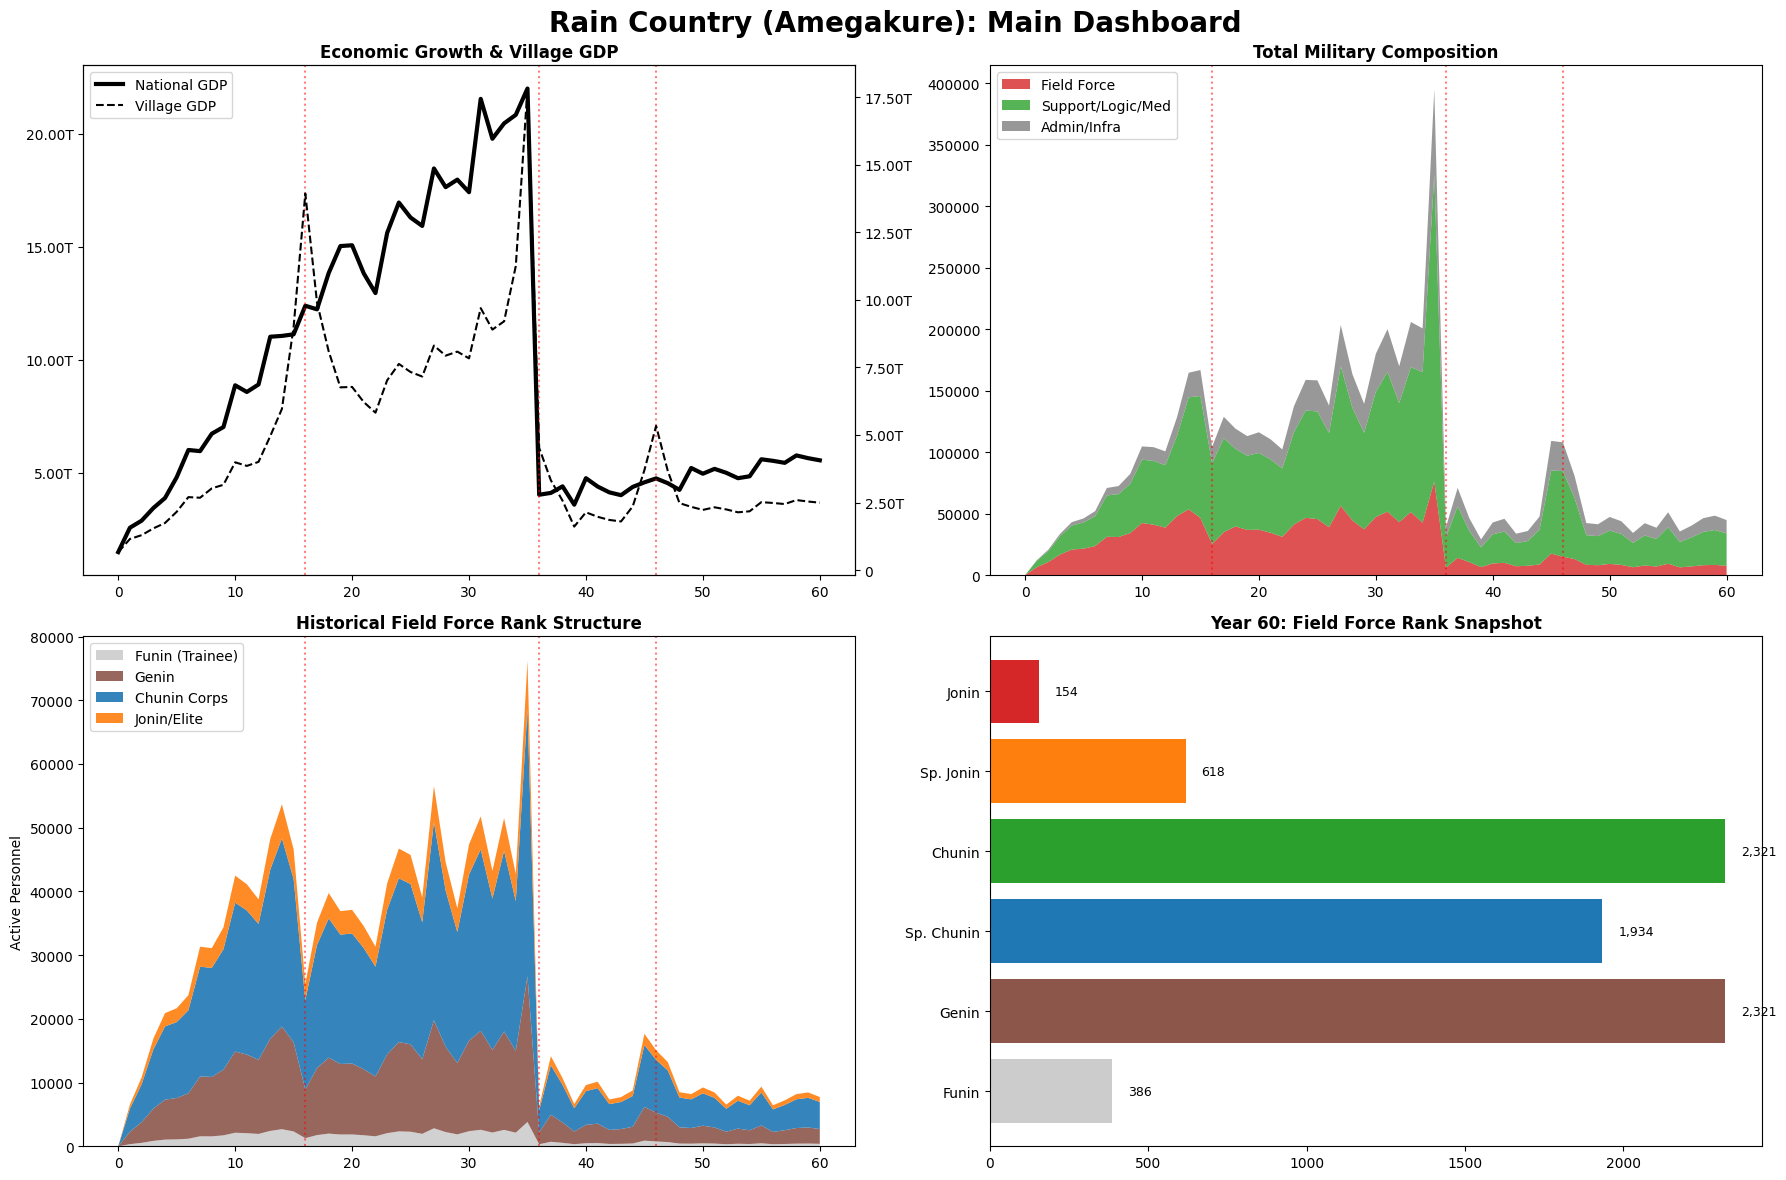

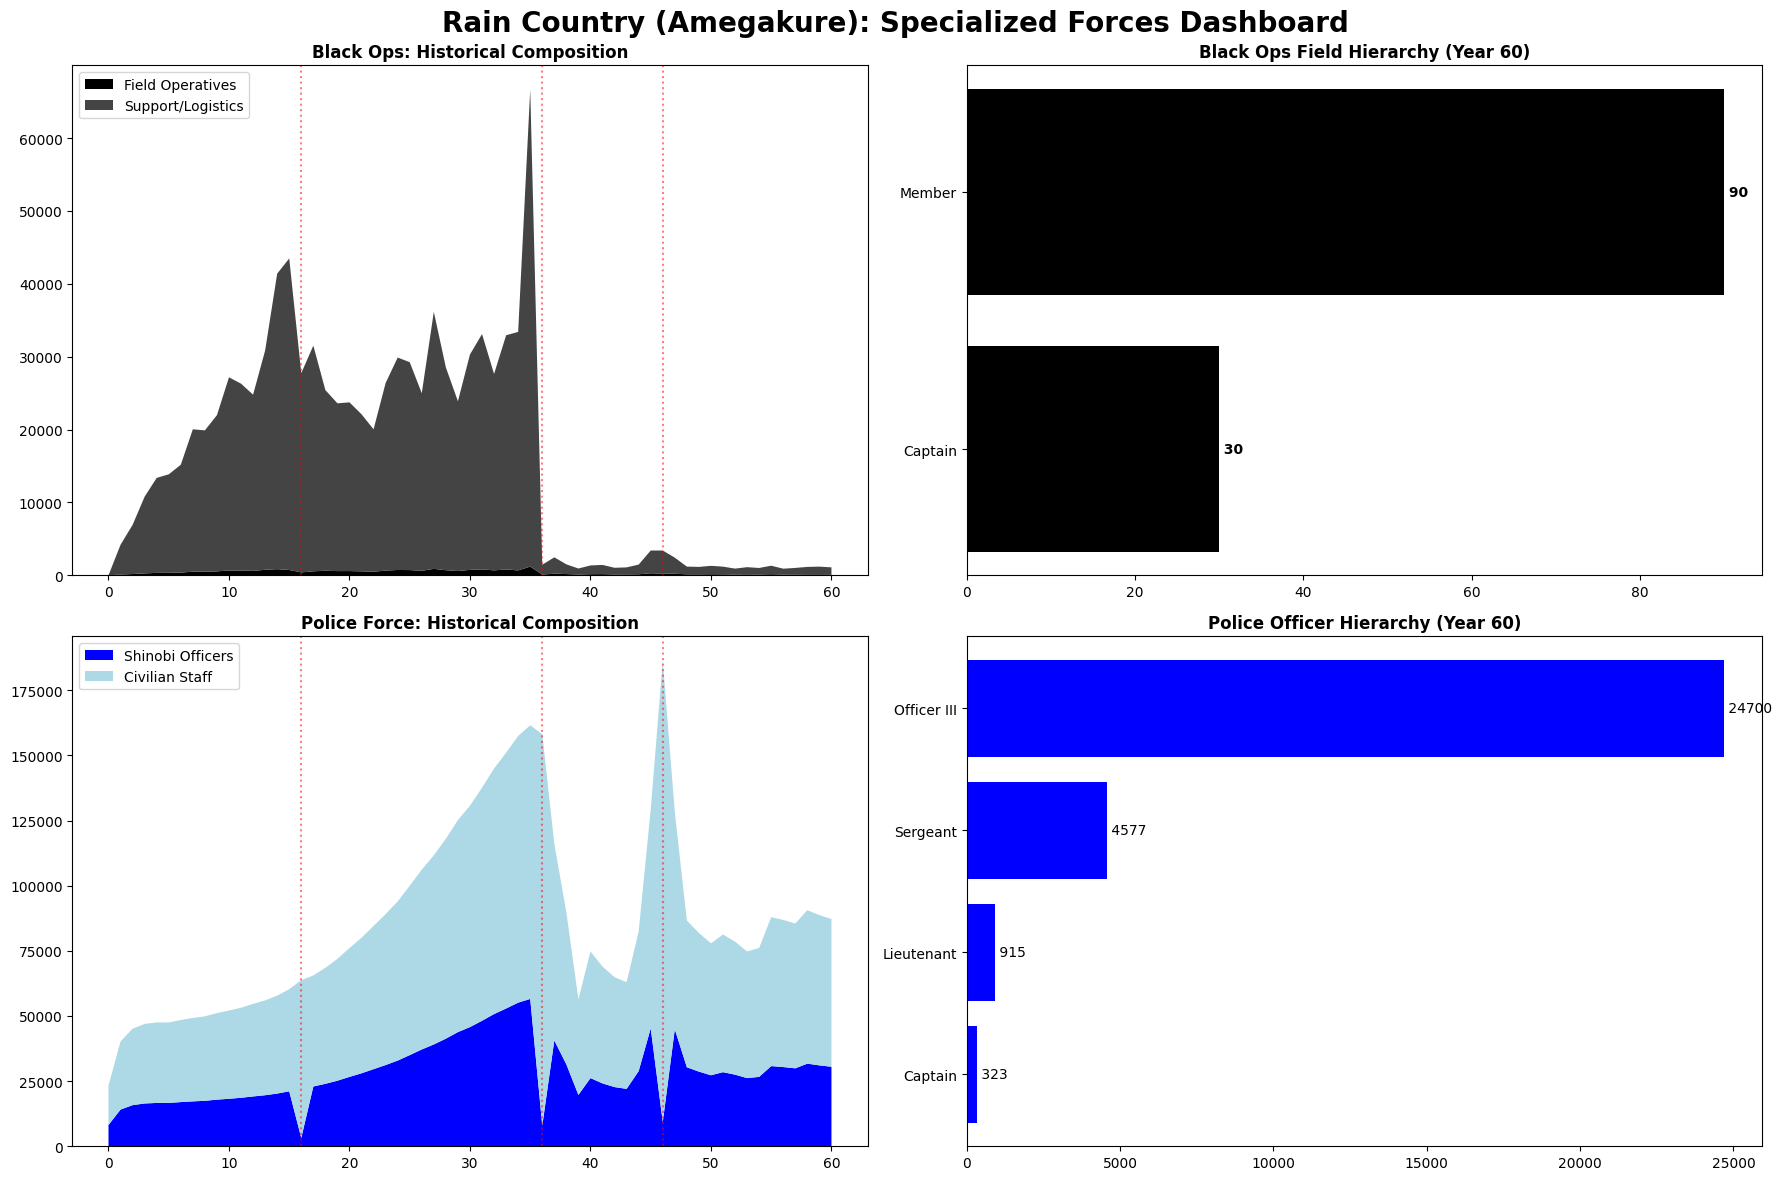

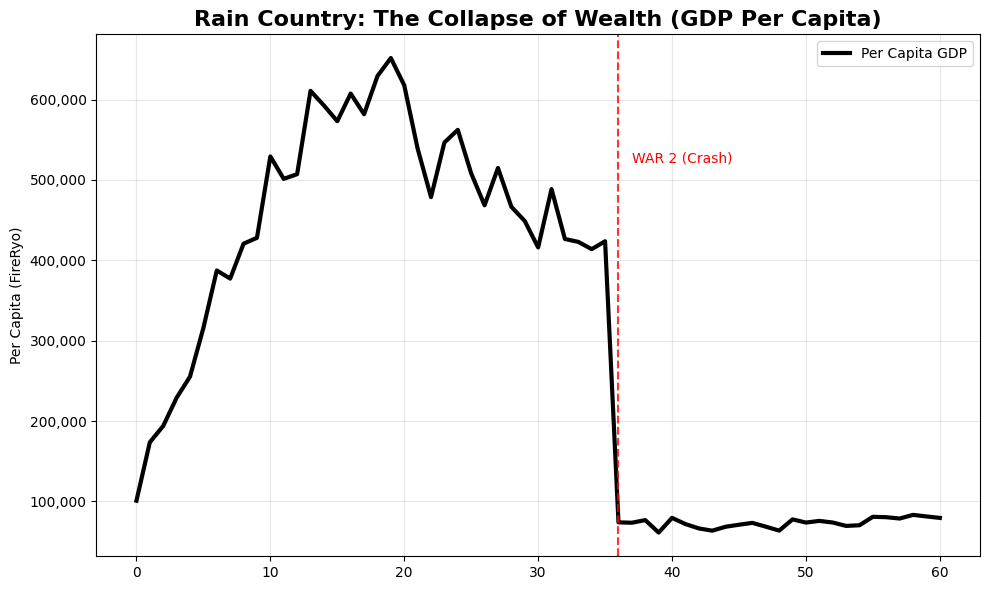

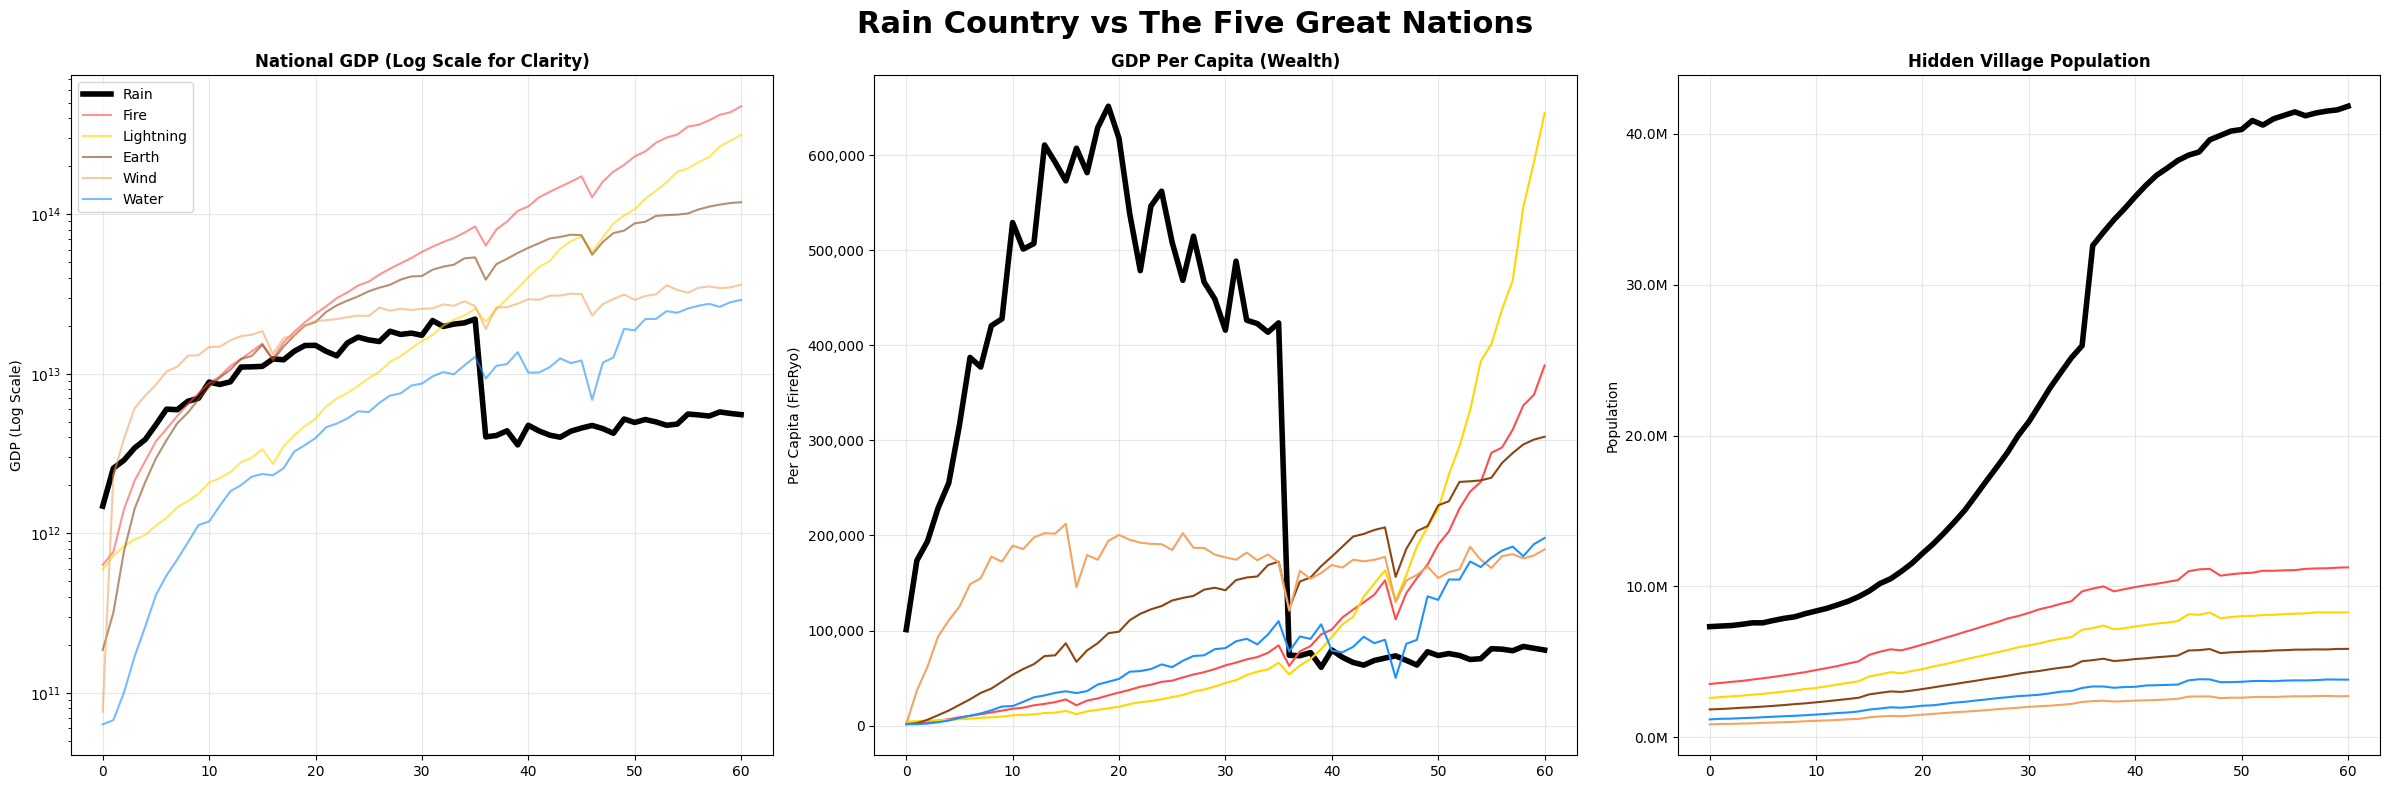

In [4]:
# ==========================================
# PART 1: RAIN CONFIGURATION (UPDATED)
# ==========================================

RANK_DOCTRINES["Rain"] = {
    "Funin": 0.05, "Genin": 0.30, "Special Chunin": 0.25, "Chunin": 0.30, "Special Jonin": 0.08, "Jonin": 0.02,
    "Support_Ability": 0.6, # Reduced support due to poverty
    "Black_Ops_Ratio_Mod": 1.3, # Pain's Regime is secretive
    "Police_Ratio_Mod": 1.5 # Theoretical high control, but limited by budget
}

RAIN_DATA = {
    "Rain": {
        "full_name": "Rain Country (Amegakure)",
        "pop_target": 70_000_000, # UPDATED: 70 Million
        "gdp_target": 7_500_000_000_000,
        "village_gdp_share": 0.45, # City-State controls almost half the wealth
        "gdp_start_b": 25,
        "village_pop_ratio": 0.50, # UPDATED: 50% Urbanization (Mega-City)
        "militarity_index": 1.5,
        "growth_style": "rain_boom_bust",
        "volatility": 0.07,
        "color": "black" # Black for visibility in comparisons
    }
}

RAW_NATIONS_DATA.update(RAIN_DATA)

# ==========================================
# PART 2: UPDATED LOGIC
# ==========================================

def get_rain_gdp_modifier(year):
    """
    1. War 1 (16): Massive War Profiteering (Supplying both sides).
    2. Years 20-35: The "Marvel" Era (Skyrocketing growth).
    3. Year 36: War 2 Destruction (The End of the Dream).
    4. Year 37+: Stagnation.
    """
    t = year / 60.0

    # 1. War 1 Profiteering (Year 16)
    if year <= 18:
        # Rapid rise to 1.8x (Profiteering)
        return 0.2 + (year / 18) * 1.6

    # 2. The Golden Age (Years 19-35)
    elif year <= 35:
        # Climbs from 1.8 to 2.8 (Industrial Marvel)
        progress = (year - 18) / 17
        return 1.8 + (1.0 * progress)

    # 3. The Crash (Year 36)
    elif year == 36:
        return 0.5 # Collapses from 2.8 to 0.5

    # 4. The Stagnation (Years 37-60)
    else:
        # Barely recovers to 0.8
        progress = (year - 36) / 24
        return 0.5 + (0.3 * progress)

def get_rain_population_logic(year, target_pop, is_village):
    # Base Logistic Growth
    t = year - 30 # Late bloomer boom
    sigmoid = 1 / (1 + math.exp(-0.15 * t))
    growth_factor = 0.20 + (0.80 * sigmoid)
    base_pop = target_pop * growth_factor

    war_mod = 1.0
    # War 2: Village population explodes (Refugees fleeing countryside)
    if year >= 36 and is_village:
        war_mod = 1.2

    return base_pop * war_mod

def adjust_support_for_war_economics(df):
    war_mults = {
        "Fire":      {"Supp": 1.60, "Admin": 1.30},
        "Lightning": {"Supp": 1.60, "Admin": 1.30},
        "Earth":     {"Supp": 1.50, "Admin": 1.15},
        "Wind":      {"Supp": 1.40, "Admin": 1.20},
        "Water":     {"Supp": 1.40, "Admin": 1.20},
        "Rain":      {"Supp": 1.70, "Admin": 1.40} # Added Rain
    }

    def get_row_mult(row):
        year = row['Year']
        nation = row['Nation']
        s_target = war_mults[nation]["Supp"]
        a_target = war_mults[nation]["Admin"]

        s_val = 1.0
        a_val = 1.0

        for wy in WAR_YEARS:
            diff = year - wy
            if diff == -2:
                s_val = 1.0 + (s_target - 1.0) * 0.3
                a_val = 1.0 + (a_target - 1.0) * 0.3
            elif diff == -1:
                s_val = 1.0 + (s_target - 1.0) * 0.6
                a_val = 1.0 + (a_target - 1.0) * 0.6
            elif diff == 0:
                s_val = s_target
                a_val = a_target
            elif diff == 1:
                s_val = 1.0 + (s_target - 1.0) * 0.5
                a_val = 1.0 + (a_target - 1.0) * 0.5

        return s_val, a_val

    for index, row in df.iterrows():
        s_mult, a_mult = get_row_mult(row)
        chaos_factor = np.random.normal(1.0, 0.05) if (s_mult > 1.0) else 1.0

        if s_mult > 1.0 or a_mult > 1.0:
            df.at[index, 'Support_Strength'] = int(row['Support_Strength'] * s_mult * chaos_factor)
            df.at[index, 'Admin_Strength'] = int(row['Admin_Strength'] * a_mult * chaos_factor)
            df.at[index, 'Black_Ops_Support'] = int(row['Black_Ops_Support'] * s_mult * chaos_factor)

    return df

# ==========================================
# PART 3: RAIN SIMULATION LOOP
# ==========================================

def run_rain_simulation():
    all_data = []
    data = RAIN_DATA["Rain"]
    nation_key = "Rain"

    start_gdp = data['gdp_start_b'] * 1_000_000_000
    end_gdp = data['gdp_target']
    doctrine = RANK_DOCTRINES[nation_key]
    volatility = data['volatility']

    for year in range(61):
        is_war = year in WAR_YEARS

        # Noise
        gdp_noise = get_realism_noise(volatility, is_war)
        pop_noise = get_realism_noise(volatility * 0.05, is_war)
        recruit_noise = get_realism_noise(volatility * 1.5, is_war)

        # Macro
        progress = get_rain_gdp_modifier(year)
        # Target acts as a "Baseline Potential", Rain exceeded it in the past
        current_gdp = (end_gdp * progress) * gdp_noise

        budget_mult = get_war_budget_modifier(year)
        village_gdp = (current_gdp * data['village_gdp_share'] * budget_mult)

        # Demographics
        current_nat_pop = get_rain_population_logic(year, data['pop_target'], False) * pop_noise
        village_target = data['pop_target'] * data['village_pop_ratio']
        current_village_pop = get_rain_population_logic(year, village_target, True) * pop_noise

        # Per Capita (Wealth Check)
        nat_per_capita = current_gdp / current_nat_pop if current_nat_pop > 0 else 0
        vil_per_capita = village_gdp / current_village_pop if current_village_pop > 0 else 0

        # --- MILITARY ---
        cost_per_ninja = 1_000_000 + (10_000_000 * (year/60))
        affordable_personnel = village_gdp / cost_per_ninja
        pop_cap = current_village_pop * 0.15
        total_personnel = min(affordable_personnel, pop_cap)

        # Rain is small (1/5th scale of giants)
        total_personnel *= 0.2

        learning = get_learning_curve_modifier(year)
        war_attrition = get_personnel_war_modifier(year)
        if year == 36: war_attrition = 0.30 # Devastating losses

        total_personnel = total_personnel * learning * war_attrition * recruit_noise

        base_support = (2 + ((12 - 2) * (year / 60))) / data['militarity_index']
        actual_support = base_support * doctrine['Support_Ability']
        field_strength = total_personnel / (1 + actual_support)

        black_ops_field = field_strength * BLACK_OPS_FIELD_PERCENT * doctrine['Black_Ops_Ratio_Mod']

        # Black Ops Support: Collapses after Golden Age
        # Golden Age (Rich): 1:40
        # Broken Age (Poor): 1:8
        bo_support_ratio = 40 if year <= 35 else 8
        black_ops_support = black_ops_field * bo_support_ratio

        remaining_tail = total_personnel - field_strength - black_ops_support
        if remaining_tail < 0: remaining_tail = 0

        admin_strength = remaining_tail * 0.3
        gen_support_strength = remaining_tail * 0.7

        # --- POLICE (POVERTY DECAY LOGIC) ---
        civilian_pop = current_village_pop - total_personnel
        ideal_police = ((civilian_pop / 1000) * OFFICERS_PER_1000_CIV) * doctrine['Police_Ratio_Mod']

        # Can they afford the police?
        # Check per capita wealth relative to a "healthy" baseline (~150k)
        wealth_factor = min(1.2, vil_per_capita / 150_000)
        # If wealth drops (Year 36+), police force gets cut

        total_police = ideal_police * wealth_factor

        current_shinobi_ratio = POLICE_SHINOBI_RATIO
        if is_war: current_shinobi_ratio = 0.05

        police_shinobi = total_police * current_shinobi_ratio
        police_civilian = total_police * (1 - current_shinobi_ratio)

        ranks = {k: int(field_strength * v) for k, v in doctrine.items() if k not in ["Support_Ability", "Black_Ops_Ratio_Mod", "Police_Ratio_Mod"]}

        stats = {
            "Nation": nation_key, "Year": year, "Is_War": is_war,
            "National_GDP": current_gdp, "Village_GDP": village_gdp,
            "National_Pop": int(current_nat_pop), "Village_Pop": int(current_village_pop),
            "National_Per_Capita": int(nat_per_capita), "Village_Per_Capita": int(vil_per_capita),
            "Field_Strength": int(field_strength), "Support_Strength": int(gen_support_strength),
            "Admin_Strength": int(admin_strength), "Black_Ops_Field": int(black_ops_field),
            "Black_Ops_Support": int(black_ops_support), "Police_Shinobi": int(police_shinobi),
            "Police_Civilian": int(police_civilian),
            "R_Funin": ranks['Funin'], "R_Genin": ranks['Genin'],
            "R_SpChunin": ranks['Special Chunin'], "R_Chunin": ranks['Chunin'],
            "R_SpJonin": ranks['Special Jonin'], "R_Jonin": ranks['Jonin']
        }
        all_data.append(stats)

    return pd.DataFrame(all_data)

# ==========================================
# EXECUTION & PLOTTING
# ==========================================

rain_df_raw = run_rain_simulation()
rain_df = adjust_support_for_war_economics(rain_df_raw)
rain_df.to_csv("Rain_Simulation_Data.csv", index=False)

# 1. Standard Rain Dashboards
plot_main_dashboard(rain_df, "Rain", RAW_NATIONS_DATA["Rain"]['color'])
plot_special_forces(rain_df, "Rain")

# 2. Rain Per Capita (New)
def plot_rain_per_capita(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title("Rain Country: The Collapse of Wealth (GDP Per Capita)", fontsize=16, fontweight='bold')
    ax.plot(df['Year'], df['National_Per_Capita'], color='black', linewidth=3, label='Per Capita GDP')

    # Mark the Crash
    ax.axvline(x=36, color='red', linestyle='--', alpha=0.8)
    ax.text(37, df['National_Per_Capita'].max()*0.8, "WAR 2 (Crash)", color='red')

    ax.set_ylabel("Per Capita (FireRyo)")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("Rain_Per_Capita.png")
    plt.show()

plot_rain_per_capita(rain_df)

# 3. GLOBAL COMPARISON (Rain vs The 5)
def plot_rain_vs_world(rain_df):
    # Try to load previous 5 nations data
    try:
        # Concatenate 5 nations CSVs
        frames = [rain_df]
        for n in ["Fire", "Lightning", "Earth", "Wind", "Water"]:
            try:
                frames.append(pd.read_csv(f"{n}_Simulation_Data.csv"))
            except: pass
        full_df = pd.concat(frames)
    except:
        print("Could not load 5 Nations data. Comparison skipped.")
        return

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle("Rain Country vs The Five Great Nations", fontsize=22, fontweight='bold')

    # A. GDP Comparison
    ax1 = axes[0]
    ax1.set_title("National GDP (Log Scale for Clarity)", fontweight='bold')
    for n in full_df['Nation'].unique():
        sub = full_df[full_df['Nation'] == n]
        is_rain = n == "Rain"
        color = RAW_NATIONS_DATA[n]['color'] if n in RAW_NATIONS_DATA else 'gray'
        width = 4 if is_rain else 1.5
        alpha = 1.0 if is_rain else 0.6
        ax1.plot(sub['Year'], sub['National_GDP'], color=color, linewidth=width, alpha=alpha, label=n)

    ax1.set_yscale('log') # Log scale because Rain is small vs Fire
    ax1.set_ylabel("GDP (Log Scale)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # B. Per Capita Comparison (The Real Story)
    ax2 = axes[1]
    ax2.set_title("GDP Per Capita (Wealth)", fontweight='bold')
    for n in full_df['Nation'].unique():
        sub = full_df[full_df['Nation'] == n]
        is_rain = n == "Rain"
        color = RAW_NATIONS_DATA[n]['color'] if n in RAW_NATIONS_DATA else 'gray'
        width = 4 if is_rain else 1.5
        ax2.plot(sub['Year'], sub['National_Per_Capita'], color=color, linewidth=width, label=n)

    ax2.set_ylabel("Per Capita (FireRyo)")
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))
    ax2.grid(True, alpha=0.3)

    # C. Village Population (Urbanization)
    ax3 = axes[2]
    ax3.set_title("Hidden Village Population", fontweight='bold')
    for n in full_df['Nation'].unique():
        sub = full_df[full_df['Nation'] == n]
        is_rain = n == "Rain"
        color = RAW_NATIONS_DATA[n]['color'] if n in RAW_NATIONS_DATA else 'gray'
        width = 4 if is_rain else 1.5
        ax3.plot(sub['Year'], sub['Village_Pop'], color=color, linewidth=width, label=n)

    ax3.set_ylabel("Population")
    ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M"))
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("Rain_Vs_World.png")
    plt.show()

plot_rain_vs_world(rain_df)
